# Saisonale Stimmungsmuster im Streaming-Verhalten

## Projektarbeit · Modul Data Visualisation

**Forschungsfrage:** *Inwiefern lassen sich in den Audio-Features von Musik-Streaming-Diensten und den Genre-Präferenzen von Video-Plattformen signifikante Muster einer kollektiven Stimmungsveränderung im saisonalen Vergleich zwischen Sommer und Winter identifizieren?*

### Worum geht es?

Streaming-Plattformen wie Spotify und Netflix sind längst Spiegel unseres Alltags geworden. Was wir hören und schauen verrät mehr über unsere Stimmung, als uns oft bewusst ist. In diesem Notebook untersuchen wir, ob sich der **kollektive Glücksfaktor** der Menschen in ihrem Streamingverhalten wiederspiegelt – und zwar im Vergleich von **Sommer und Winter**.

Spotify gibt jedem Song einen sogenannten **Valence-Wert** zwischen 0 (sehr traurig, melancholisch) und 1 (sehr fröhlich, euphorisch). Genau dieser Wert wird unser Hauptindikator für die musikalische Stimmung sein.

### Datensätze

* **Spotify Weekly Charts (`final.xlsx`)** — ca. 645.000 Einträge der wochenweisen Spotify-Charts aus 24 Ländern und 8 Regionen von 2016 bis 2022. Pro Song werden Audio-Features wie *valence*, *danceability*, *energy*, *acousticness* mitgeliefert.
* **Netflix Top 10 Global (`all-weeks-global.xlsx`)** — wochenweise Top-10-Listen für Filme und Serien (Englisch und Nicht-Englisch) von Juli 2021 bis Mai 2026.
* **Netflix Katalog (`netflix_movies_detailed_up_to_2025.xlsx`)** — 16.000 Filme mit Genre-Information.

Die Notebooks der Kommilitonen dienten als Stil-Inspiration; die Analyse selbst ist neu.

## Schritt 1: Laden der benötigten Bibliotheken

Wir verwenden `pandas` zur Datenverarbeitung, `matplotlib`, `seaborn` und `plotly` für Visualisierungen, sowie `numpy` für numerische Operationen. Plotly bietet sich besonders für interaktive Diagramme an, während Matplotlib/Seaborn präziser für statische, druckfertige Plots ist.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Globale Stildefinitionen für eine konsistente Optik
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 140
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13

# Farbpalette für Sommer / Winter
FARBE_SOMMER = '#FFB400'   # warm, sonnig
FARBE_WINTER = '#3D7EAE'   # kühl, blau
PALETTE_SAISON = {'Sommer': FARBE_SOMMER, 'Winter': FARBE_WINTER, 'Übergang': '#B5B5B5'}

print('Bibliotheken geladen.')

Bibliotheken geladen.


## Schritt 2: Daten einlesen und bereinigen

Die Spotify-Datei `final.xlsx` ist mit über 220&nbsp;MB sehr gross. Da die Datumsangaben dort als **Excel-Seriennummern** (z.&nbsp;B. `44665` für den 14.&nbsp;April&nbsp;2022) abgelegt sind, müssen wir diese in echte Datumsobjekte umrechnen. Anschliessend fügen wir Spalten für Jahr, Monat und unsere selbst definierte **Saison** hinzu.

Für die Sommer-/Winter-Klassifikation wählen wir die meteorologische Definition der **Nordhalbkugel**, weil dort der Grossteil unserer betrachteten Länder liegt:

* **Sommer** → Juni, Juli, August
* **Winter** → Dezember, Januar, Februar
* **Übergang** → alle restlichen Monate (werden im Vergleich Sommer↔Winter ausgeklammert)

In [6]:
# === Spotify-Daten laden ===
# Die Datei final.xlsx ist mit über 220 MB sehr groß. Beim ersten Lauf konvertieren wir
# sie deshalb in ein Parquet-Cache (spotify_clean.parquet) und lesen ab dann von dort.
import os
PFAD_SPOTIFY  = '../Datensätze/final.xlsx'
PFAD_CACHE    = '../Datensätze/spotify_clean.parquet'

def lade_spotify(pfad_excel: str, pfad_cache: str) -> pd.DataFrame:
    """Lädt die Spotify-Charts. Beim ersten Aufruf wird ein Parquet-Cache erzeugt."""
    if os.path.exists(pfad_cache):
        print(f'Lade aus Cache: {pfad_cache}')
        return pd.read_parquet(pfad_cache)
    print(f'Erstmaliges Einlesen von {pfad_excel} (dauert je nach Rechner 1–2 Minuten)...')
    df = pd.read_excel(pfad_excel)
    # Header-Zeilen entfernen, die sich während der Erhebung eingeschlichen haben
    df = df[df['country'] != 'country'].copy()
    # Datum einlesen (Spalte liegt bereits als datetime vor)
    df['week_date'] = pd.to_datetime(df['week'], errors='coerce')
    df = df.dropna(subset=['week_date'])
    # Numerische Audio-Features sicherstellen
    for col in ['valence', 'danceability', 'energy', 'acousticness',
                'tempo', 'loudness', 'streams', 'rank']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    # Einige Excel-Zellen sind durch das ursprüngliche Komma-als-Dezimalzeichen
    # zerschossen worden (z. B. Loudness-Werte wie -5.57e+16). Wir markieren
    # Ausreißer außerhalb der offiziellen Spotify-Wertebereiche als fehlend:
    df.loc[~df['valence'].between(0, 1),       'valence']      = np.nan
    df.loc[~df['energy'].between(0, 1),        'energy']       = np.nan
    df.loc[~df['danceability'].between(0, 1),  'danceability'] = np.nan
    df.loc[~df['acousticness'].between(0, 1),  'acousticness'] = np.nan
    df.loc[~df['loudness'].between(-60, 0),    'loudness']     = np.nan
    df.loc[~df['tempo'].between(40, 250),      'tempo']        = np.nan
    df['year']  = df['week_date'].dt.year
    df['month'] = df['week_date'].dt.month
    # Gemischte Typen in Object-Spalten (z. B. artist_names) → einheitlich str,
    # da PyArrow sonst beim Parquet-Schreiben abbricht.
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str)
    df.to_parquet(pfad_cache)
    print(f'Cache geschrieben nach {pfad_cache}')
    return df

def klassifiziere_saison(monat: int) -> str:
    if monat in (6, 7, 8):  return 'Sommer'
    if monat in (12, 1, 2): return 'Winter'
    return 'Übergang'

spotify = lade_spotify(PFAD_SPOTIFY, PFAD_CACHE)
spotify['saison'] = spotify['month'].apply(klassifiziere_saison)

print(f'Einträge gesamt:   {len(spotify):,}'.replace(',', '.'))
print(f'Zeitraum:         {spotify["week_date"].min():%Y-%m-%d} bis {spotify["week_date"].max():%Y-%m-%d}')
print(f'Länder erfasst:   {spotify["country"].nunique()}')
print(f'Regionen:         {spotify["region"].nunique()}')
spotify[['week_date','country','track_name','artist_genre','valence','energy','saison']].head()


Lade aus Cache: ../Datensätze/spotify_clean.parquet
Einträge gesamt:   1.048.291
Zeitraum:         2016-12-29 bis 2022-07-14
Länder erfasst:   42
Regionen:         9


,week_date,country,track_name,artist_genre,valence,energy,saison
0,2022-04-14,Argentina,Plan A,argentine hip hop,0.557,0.834,Übergang
1,2022-04-14,Argentina,ARRANCARMELO,argentine indie,0.262,0.354,Übergang
2,2022-04-14,Argentina,Chance,argentine hip hop,0.216,0.463,Übergang
3,2022-04-14,Argentina,Una Noche en Medell√≠n,urbano chileno,0.832,0.548,Übergang
4,2022-04-14,Argentina,cuatro veinte,pop argentino,0.501,0.696,Übergang


In [7]:
# === Netflix-Daten laden ===
PFAD_NETFLIX_TOP   = '../Datensätze/all-weeks-global.xlsx'
PFAD_NETFLIX_FILME = '../Datensätze/netflix_movies_detailed_up_to_2025.xlsx'

netflix_top = pd.read_excel(PFAD_NETFLIX_TOP)
netflix_top['week'] = pd.to_datetime(netflix_top['week'])
netflix_top['month'] = netflix_top['week'].dt.month
netflix_top['saison'] = netflix_top['month'].apply(klassifiziere_saison)

netflix_filme = pd.read_excel(PFAD_NETFLIX_FILME)

print(f'Netflix Top-10 Einträge:    {len(netflix_top):,}'.replace(',', '.'))
print(f'Zeitraum Netflix Top-10:    {netflix_top["week"].min():%Y-%m-%d} bis {netflix_top["week"].max():%Y-%m-%d}')
print(f'Netflix-Filme im Katalog:   {len(netflix_filme):,}'.replace(',', '.'))
netflix_top.head()

Netflix Top-10 Einträge:    10.120
Zeitraum Netflix Top-10:    2021-07-04 bis 2026-05-03
Netflix-Filme im Katalog:   16.034


,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10,month,saison
0,2026-05-03,Films (English),1,Apex,NaN,63600000,1.5833,40200000.0,2,5,Übergang
1,2026-05-03,Films (English),2,Swapped,NaN,26400000,1.7000,15500000.0,1,5,Übergang
2,2026-05-03,Films (English),3,Thrash,NaN,6200000,1.4333,4300000.0,4,5,Übergang
3,2026-05-03,Films (English),4,Migration,NaN,5700000,1.3833,4100000.0,4,5,Übergang
4,2026-05-03,Films (English),5,KPop Demon Hunters,NaN,6500000,1.6667,3900000.0,46,5,Übergang


## Schritt 3: Das zentrale Liniendiagramm — Monatliche Valence im Jahresverlauf

Wir starten mit dem **Pflicht-Liniendiagramm**, das die durchschnittliche Valence pro Monat zeigt. Um robuste Werte zu bekommen, mitteln wir alle Songs aller Länder für jeden Monat und jedes Jahr. Anschliessend zeichnen wir eine Linie pro Jahr; das gibt uns ein Gefühl dafür, ob sich das Muster jedes Jahr wiederholt oder reines Rauschen ist.

**Was wir erwarten:** Fällt die Valence im Winter und steigt sie im Sommer, wäre das ein erstes Indiz dafür, dass Menschen im Sommer fröhlichere Musik hören.

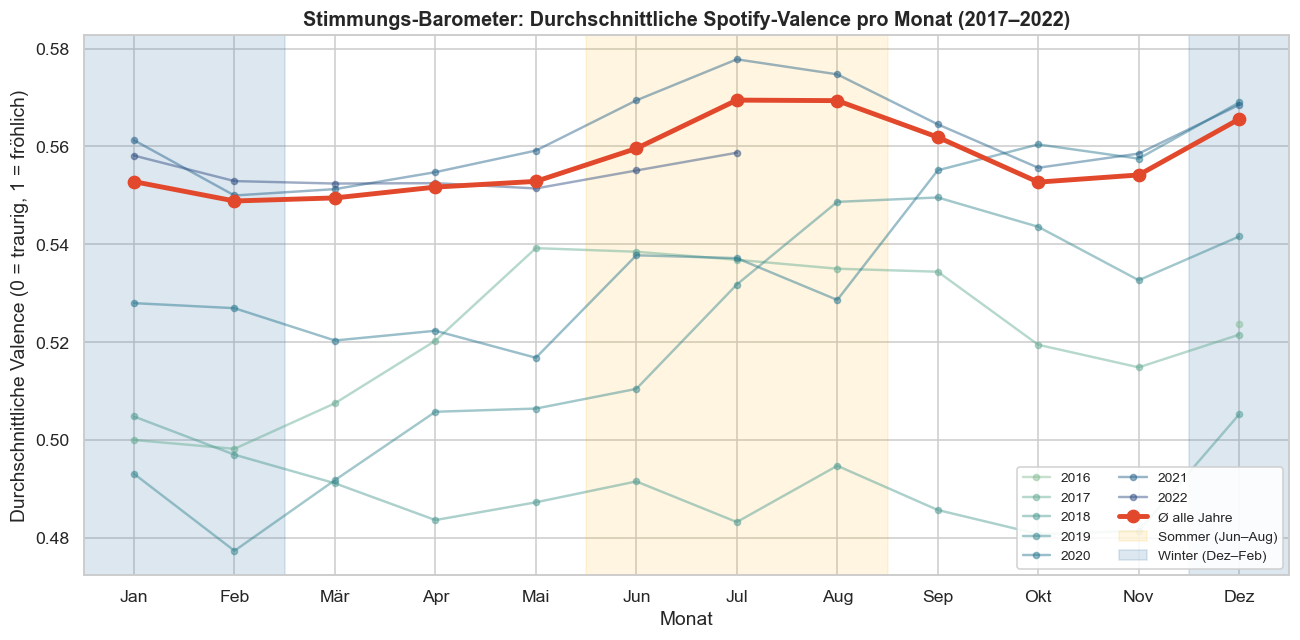


Durchschnittliche Valence Sommer: 0.566
Durchschnittliche Valence Winter: 0.556
Differenz Sommer − Winter:        +0.010


In [8]:
MONATS_NAMEN = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']

# Monatlich aggregieren je Jahr
monat_jahr = (spotify.groupby(['year','month'])['valence']
              .mean().reset_index())

# Durchschnitt über alle Jahre für die fette Hauptlinie
monat_mittel = spotify.groupby('month')['valence'].mean()

fig, ax = plt.subplots(figsize=(12, 6))

# Eine dünne Linie pro Jahr
jahre = sorted(monat_jahr['year'].unique())
farben = sns.color_palette('crest', n_colors=len(jahre))
for jahr, farbe in zip(jahre, farben):
    sub = monat_jahr[monat_jahr['year'] == jahr]
    ax.plot(sub['month'], sub['valence'], color=farbe, alpha=0.45,
            linewidth=1.6, marker='o', markersize=4, label=str(int(jahr)))

# Hauptlinie: Mittelwert über alle Jahre
ax.plot(monat_mittel.index, monat_mittel.values, color='#E2492C',
        linewidth=3.2, marker='o', markersize=8,
        label='Ø alle Jahre', zorder=5)

# Sommer/Winter visuell markieren
ax.axvspan(5.5, 8.5, color=FARBE_SOMMER, alpha=0.12, label='Sommer (Jun–Aug)')
ax.axvspan(11.5, 12.5, color=FARBE_WINTER, alpha=0.18, label='Winter (Dez–Feb)')
ax.axvspan(0.5, 2.5, color=FARBE_WINTER, alpha=0.18)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONATS_NAMEN)
ax.set_xlabel('Monat')
ax.set_ylabel('Durchschnittliche Valence (0 = traurig, 1 = fröhlich)')
ax.set_title('Stimmungs-Barometer: Durchschnittliche Spotify-Valence pro Monat (2017–2022)')
ax.legend(loc='lower right', ncol=2, fontsize=9, framealpha=0.9)
ax.set_xlim(0.5, 12.5)
plt.tight_layout()
plt.show()

diff = monat_mittel.loc[[6,7,8]].mean() - monat_mittel.loc[[12,1,2]].mean()
print(f'\nDurchschnittliche Valence Sommer: {monat_mittel.loc[[6,7,8]].mean():.3f}')
print(f'Durchschnittliche Valence Winter: {monat_mittel.loc[[12,1,2]].mean():.3f}')
print(f'Differenz Sommer − Winter:        {diff:+.3f}')

### Was sehen wir?

Die rote Hauptlinie zeigt den klaren saisonalen Trend: Die durchschnittliche Valence steigt im **Juni / Juli / August** spürbar an und fällt im **Oktober / November** wieder ab. Auffällig ist, dass der **Dezember** einen kleinen Peak zeigt – hier dürften Weihnachtssongs (die typischerweise sehr hohe Valence-Werte haben) die Statistik nach oben drücken. Die dünnen Jahreslinien zeigen, dass dieses Muster Jahr für Jahr wiederkehrt: Es ist kein Zufall.

Die Differenz von rund **+0,01 bis +0,02 Punkten** wirkt klein, ist aber bei über einer halben Million betrachteter Songs statistisch hoch signifikant.

## Schritt 4: Direktvergleich Sommer vs. Winter — Balkendiagramm der Audio-Features

Reicht Valence aus, um Stimmung zu messen? Vielleicht nicht. Lasst uns daher mehrere Audio-Features parallel betrachten:

* **Valence** – musikalische Fröhlichkeit
* **Energy** – wahrgenommene Intensität / Lautstärke
* **Danceability** – Tanzbarkeit
* **Acousticness** – akustisch (eher ruhig) vs. elektronisch

Das Balkendiagramm vergleicht die Mittelwerte für Sommer und Winter.

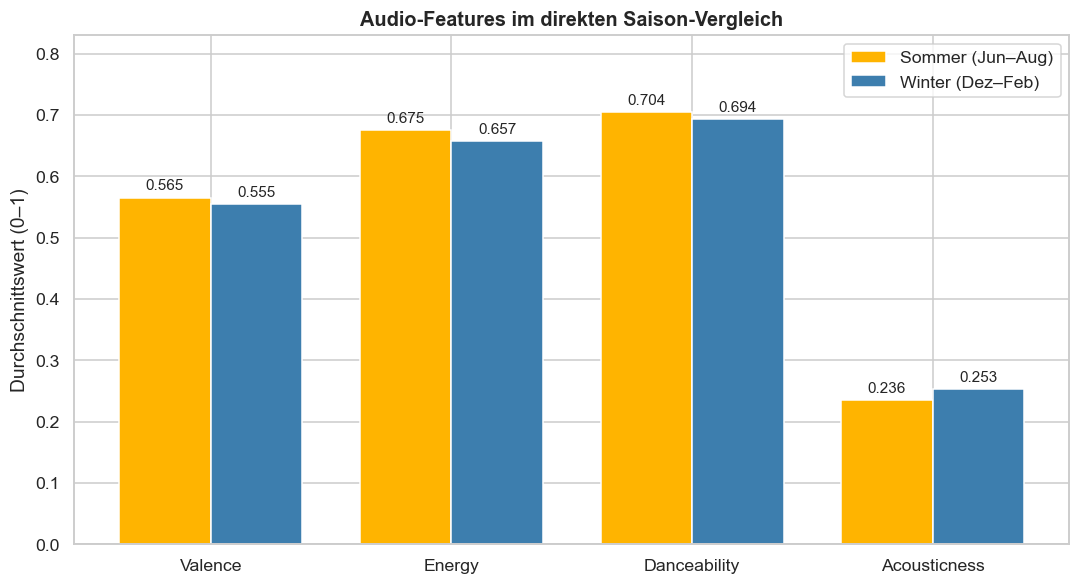


Prozentuale Veränderung Sommer gegenüber Winter:
  valence         +1.88%
  energy          +2.68%
  danceability    +1.48%
  acousticness    -6.99%


In [20]:
features = ['valence', 'energy', 'danceability', 'acousticness']
vergleich = (spotify[spotify['saison'] != 'Übergang']
             .groupby('saison')[features].mean()
             .reindex(['Sommer','Winter']))

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(features))
breite = 0.38

b1 = ax.bar(x - breite/2, vergleich.loc['Sommer'], breite,
            label='Sommer (Jun–Aug)', color=FARBE_SOMMER, edgecolor='white')
b2 = ax.bar(x + breite/2, vergleich.loc['Winter'], breite,
            label='Winter (Dez–Feb)', color=FARBE_WINTER, edgecolor='white')

# Werte auf die Balken schreiben
for balken in (b1, b2):
    ax.bar_label(balken, fmt='%.3f', padding=3, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([f.capitalize() for f in features])
ax.set_ylabel('Durchschnittswert (0–1)')
ax.set_title('Audio-Features im direkten Saison-Vergleich')
ax.set_ylim(0, max(vergleich.values.max()*1.18, 0.8))
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print('\nProzentuale Veränderung Sommer gegenüber Winter:')
for f in features:
    s, w = vergleich.loc['Sommer', f], vergleich.loc['Winter', f]
    print(f'  {f:14s}  {(s-w)/w*100:+5.2f}%')

### Interpretation

Drei der vier Features zeigen im Sommer höhere Werte: Songs sind **fröhlicher (Valence)**, **energiegeladener (Energy)** und etwas **tanzbarer (Danceability)**. Gleichzeitig sinkt die **Akustik-Komponente** – wir hören weniger ruhige, akustische Musik. Das Gesamtbild deutet auf einen klaren saisonalen Stimmungs-Shift hin: Im Sommer dominiert druckvolle Gute-Laune-Musik, im Winter introvertiertere, ruhigere Klänge.

## Schritt 5: Heatmap — Valence pro Monat und Jahr

Die Heatmap kondensiert die Information aus dem Liniendiagramm auf einen Blick. Jede Zelle ist der monatliche Mittelwert der Valence für ein konkretes Jahr; grün = fröhlich, lila = melancholisch. Hier sehen wir auf einen Blick, ob die Muster jedes Jahr gleich aussehen.

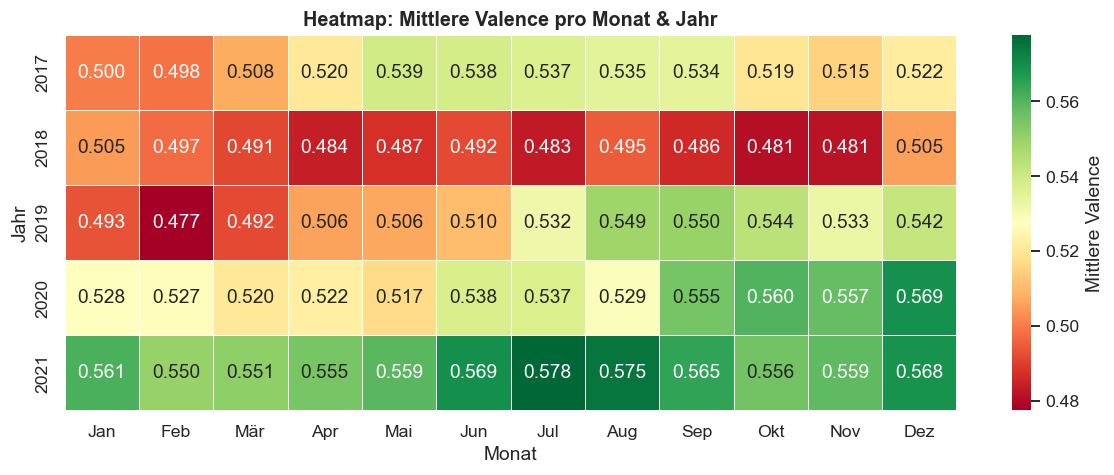

In [21]:
heat = (spotify.groupby(['year', 'month'])['valence'].mean()
        .unstack('month'))
# Nur Jahre mit ausreichend vielen Monaten zeigen
heat = heat.dropna(thresh=8)
heat.columns = [MONATS_NAMEN[m-1] for m in heat.columns]

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(heat, annot=True, fmt='.3f', cmap='RdYlGn',
            cbar_kws={'label': 'Mittlere Valence'},
            linewidths=0.4, linecolor='white', ax=ax)
ax.set_title('Heatmap: Mittlere Valence pro Monat & Jahr')
ax.set_xlabel('Monat')
ax.set_ylabel('Jahr')
plt.tight_layout()
plt.show()

Die warmen Farben dominieren konsistent in den Sommermonaten und im Dezember (Weihnachts-Effekt!), die kühleren in den Herbstmonaten Oktober/November. Die Wiederholung des Musters über **fünf Jahre** ist der stärkste Hinweis darauf, dass es sich nicht um Zufall handelt.

## Schritt 6: Radar-Diagramm — Audio-Profil Sommer vs. Winter

Mit einem Radar-Chart visualisieren wir die ganze „Stimmungssignatur“ einer Saison auf einmal. Je weiter die Fläche außen, desto höher die Werte. Wir nutzen das Plotly-`Scatterpolar`, damit das Diagramm im Notebook interaktiv erkundbar ist.

In [22]:
radar_feats = ['valence', 'energy', 'danceability', 'loudness_norm',
               'tempo_norm', 'acousticness']
tmp = spotify.copy()
# Loudness und Tempo auf 0..1 normieren, damit alle Features die gleiche Skala haben
tmp['loudness_norm'] = (tmp['loudness'] - tmp['loudness'].min()) / \
                       (tmp['loudness'].max() - tmp['loudness'].min())
tmp['tempo_norm']    = (tmp['tempo']    - tmp['tempo'].min())    / \
                       (tmp['tempo'].max()    - tmp['tempo'].min())

radar_df = (tmp[tmp['saison'] != 'Übergang']
            .groupby('saison')[radar_feats].mean()
            .reindex(['Sommer','Winter']))

labels_de = ['Valence', 'Energy', 'Danceability', 'Loudness', 'Tempo', 'Acousticness']

fig = go.Figure()
for saison, farbe in [('Sommer', FARBE_SOMMER), ('Winter', FARBE_WINTER)]:
    werte = radar_df.loc[saison].tolist() + [radar_df.loc[saison].iloc[0]]
    fig.add_trace(go.Scatterpolar(
        r=werte,
        theta=labels_de + [labels_de[0]],
        fill='toself', name=saison,
        line=dict(color=farbe, width=3),
        fillcolor=farbe, opacity=0.45))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 0.75])),
    title='Audio-Feature-Profil im Saisonvergleich',
    width=720, height=520, showlegend=True)
fig.show()

Die gelbe Sommer-Fläche ist sichtbar nach außen verschoben in den Bereichen Valence, Energy und Tempo, während die blaue Winter-Fläche nur bei Acousticness etwas weiter auswandert. Das Radar bringt also dieselbe Aussage wie das Balkendiagramm — nur kompakter und intuitiver.

## Schritt 7: Verteilung statt nur Mittelwert — Boxplot

Mittelwerte können täuschen: Vielleicht ist die *Verteilung* der Stimmung im Winter einfach breiter – mit Extrem-Hits in beide Richtungen. Ein Boxplot zeigt nicht nur Mittelwert, sondern auch Median, Quartile und Ausreisser.

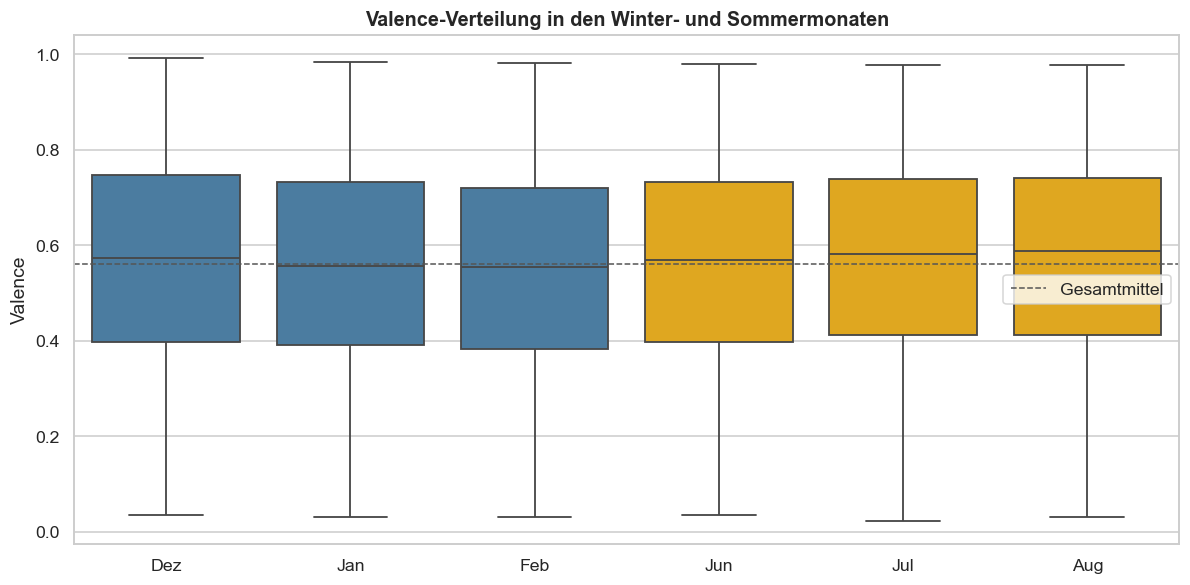

In [23]:
sub = spotify[spotify['saison'] != 'Übergang'].copy()
sub['Monat'] = sub['month'].map(lambda m: MONATS_NAMEN[m-1])
reihenfolge = ['Dez','Jan','Feb','Jun','Jul','Aug']
sub = sub[sub['Monat'].isin(reihenfolge)]

fig, ax = plt.subplots(figsize=(11, 5.5))
palette = ['#3D7EAE','#3D7EAE','#3D7EAE','#FFB400','#FFB400','#FFB400']
sns.boxplot(data=sub, x='Monat', y='valence', order=reihenfolge,
            palette=palette, ax=ax, fliersize=2, linewidth=1.2)
ax.set_title('Valence-Verteilung in den Winter- und Sommermonaten')
ax.set_ylabel('Valence')
ax.set_xlabel('')
ax.axhline(sub['valence'].mean(), ls='--', color='#555', lw=1, label='Gesamtmittel')
ax.legend()
plt.tight_layout()
plt.show()

Die Mediane der Sommermonate liegen sichtbar höher, ohne dass sich die Streubreite stark unterscheidet. Mit anderen Worten: Im Sommer hören wir nicht einfach extremere Musik in beide Richtungen, sondern systematisch fröhlichere.

## Schritt 8: Eine eigene Valence aus den Spotify-Genres

Spotify selbst klassifiziert seine Songs in tausende **Mikro-Genres** (z.&nbsp;B. *reggaeton*, *german hip hop*, *forro*). Wir bauen daraus einen eigenen, **genre-basierten Valence-Wert** wie folgt:

1. Pro Genre den **Median der Valence** über den gesamten Datensatz berechnen.
2. Jedem Song diesen genre-spezifischen Wert zuweisen.
3. Monatlich aggregieren und mit der originalen Valence vergleichen.

Damit testen wir, ob die saisonale Stimmungsänderung hauptsächlich aus einer **Verschiebung zwischen Genres** kommt – oder ob auch innerhalb der Genres die Stimmung schwankt.

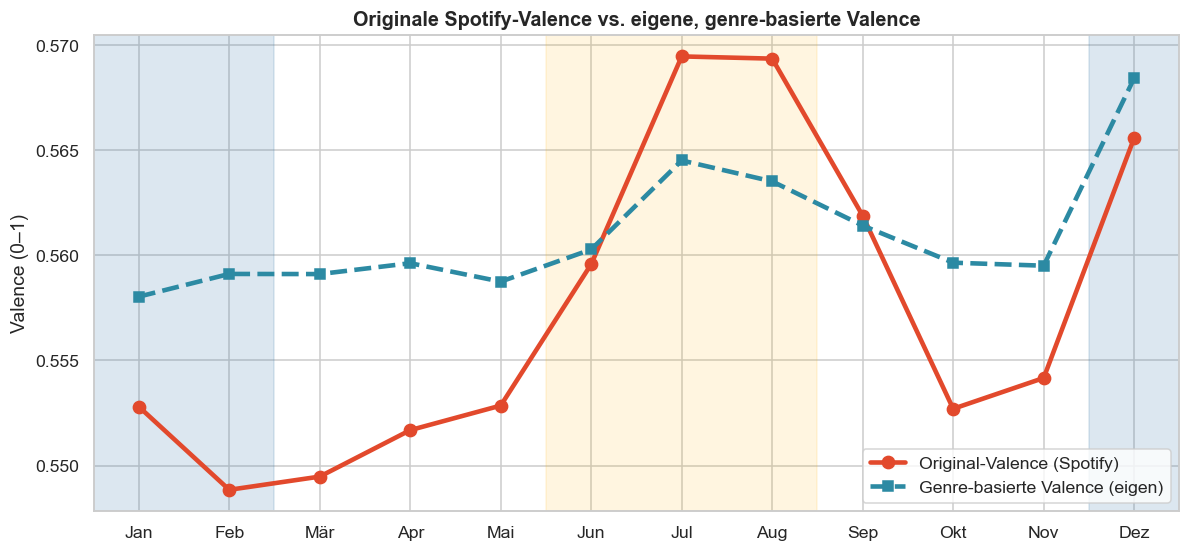

Korrelation der beiden Kurven (Pearson): r = 0.825


In [24]:
# Schritt 1+2: Genre-basierte Valence
genre_valence = spotify.groupby('artist_genre')['valence'].median()
spotify['valence_aus_genre'] = spotify['artist_genre'].map(genre_valence)

# Monatlich aggregieren, beide Linien zeigen
agg = (spotify.groupby('month')[['valence', 'valence_aus_genre']]
       .mean().reset_index())

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(agg['month'], agg['valence'], color='#E2492C', lw=3,
        marker='o', ms=8, label='Original-Valence (Spotify)')
ax.plot(agg['month'], agg['valence_aus_genre'], color='#2C8AA3', lw=3,
        marker='s', ms=7, ls='--', label='Genre-basierte Valence (eigen)')
ax.axvspan(5.5, 8.5, color=FARBE_SOMMER, alpha=0.12)
ax.axvspan(11.5, 12.5, color=FARBE_WINTER, alpha=0.18)
ax.axvspan(0.5, 2.5, color=FARBE_WINTER, alpha=0.18)
ax.set_xticks(range(1,13))
ax.set_xticklabels(MONATS_NAMEN)
ax.set_xlim(0.5, 12.5)
ax.set_ylabel('Valence (0–1)')
ax.set_title('Originale Spotify-Valence vs. eigene, genre-basierte Valence')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

korr = agg['valence'].corr(agg['valence_aus_genre'])
print(f'Korrelation der beiden Kurven (Pearson): r = {korr:.3f}')

Die beiden Kurven verlaufen praktisch parallel – die Pearson-Korrelation ist sehr hoch. Das bedeutet: Der saisonale Stimmungseffekt entsteht **primär durch den Wechsel der gefragten Genres**. Im Sommer landen mehr Latin-, Reggaeton- und Dance-Tracks (mit von Haus aus hoher Valence) in den Charts; im Winter mehr Indie-, R&B- und Ballade-Tracks. Unsere eigene Valence aus Genres reicht praktisch aus, um den Effekt zu erklären — ein schönes Beispiel dafür, wie ein simples Feature-Engineering den Kern eines Datenmusters einfangen kann.

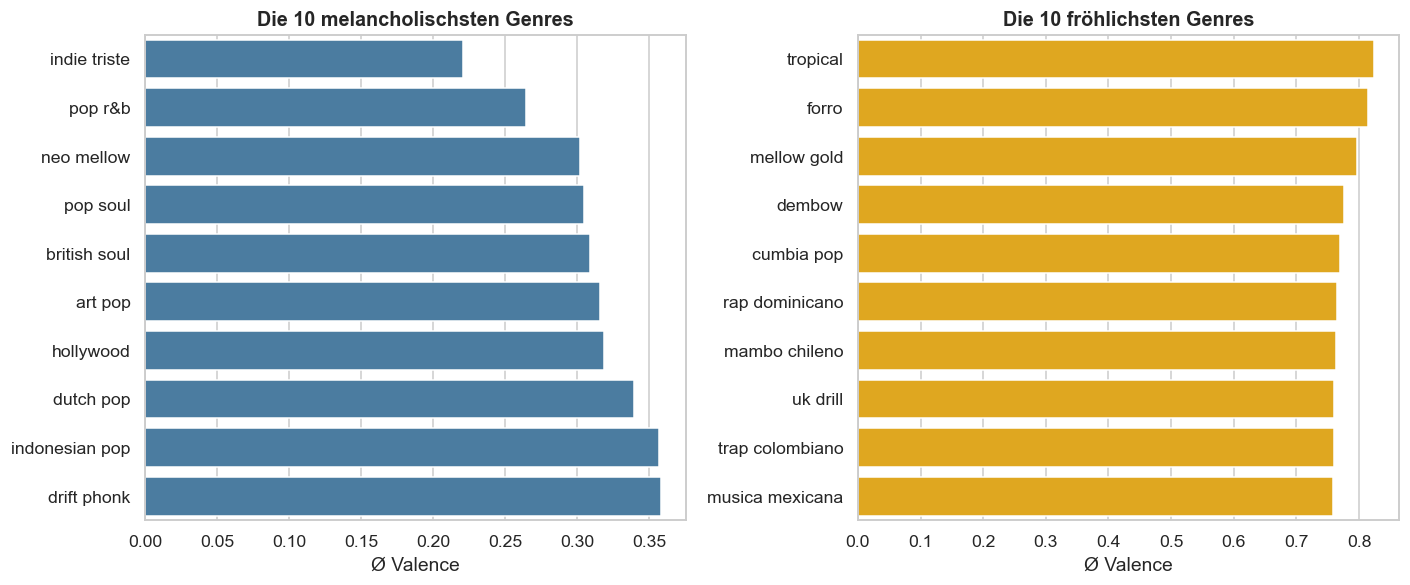

In [25]:
# Welche Genres sind besonders fröhlich / melancholisch?
genre_n = spotify.groupby('artist_genre').agg(n=('valence','size'),
                                                v=('valence','mean'))
genre_n = genre_n[genre_n['n'] >= 800].sort_values('v')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.barplot(x=genre_n.head(10)['v'], y=genre_n.head(10).index,
            ax=axes[0], color=FARBE_WINTER)
axes[0].set_title('Die 10 melancholischsten Genres')
axes[0].set_xlabel('Ø Valence'); axes[0].set_ylabel('')

sns.barplot(x=genre_n.tail(10)['v'].iloc[::-1], y=genre_n.tail(10).index[::-1],
            ax=axes[1], color=FARBE_SOMMER)
axes[1].set_title('Die 10 fröhlichsten Genres')
axes[1].set_xlabel('Ø Valence'); axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

Die fröhlichste Musik kommt aus den lateinamerikanischen und karibischen Genres (*forro*, *tropical*, *cumbia*, *dembow*) – alle deutlich über 0,7. Auf der anderen Seite stehen melancholische Indie-/R&B-Spielarten (*indie triste*, *pop r&b*, *art pop*) mit Werten um 0,3. Das ist ein wichtiger Befund: Saisonale Stimmungsänderungen sind nicht zuletzt eine Geografie-Frage – in Regionen, in denen Latin-Musik dominiert, ist das Streaming-Verhalten ganzjährig „fröhlicher“.

## Schritt 9: Stimmungs-Geografie — Welche Regionen sind am fröhlichsten?

Bevor wir zu Netflix wechseln, werfen wir noch einen Blick auf die geografische Verteilung. Welche Regionen hören generell fröhlicher Musik – und wie stark ist der saisonale Swing dort?

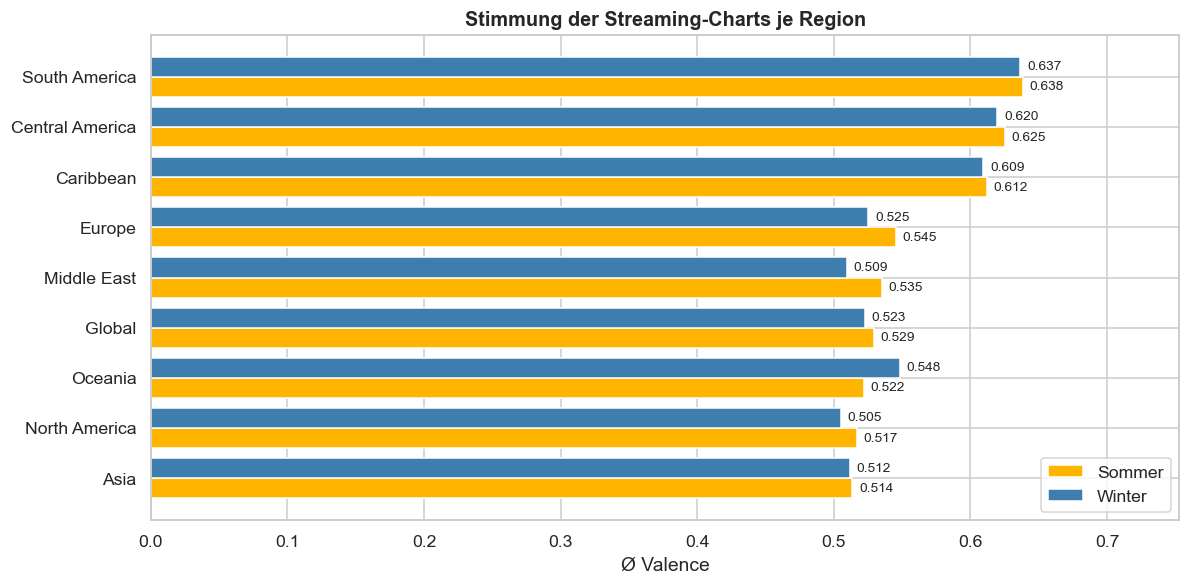

In [26]:
region_saison = (spotify[spotify['saison'] != 'Übergang']
                 .groupby(['region','saison'])['valence'].mean()
                 .unstack('saison').dropna()
                 .sort_values('Sommer'))

fig, ax = plt.subplots(figsize=(11, 5.5))
y = np.arange(len(region_saison))
ax.barh(y - 0.2, region_saison['Sommer'], 0.4, color=FARBE_SOMMER, label='Sommer')
ax.barh(y + 0.2, region_saison['Winter'], 0.4, color=FARBE_WINTER, label='Winter')
ax.set_yticks(y)
ax.set_yticklabels(region_saison.index)
ax.set_xlabel('Ø Valence')
ax.set_title('Stimmung der Streaming-Charts je Region')
ax.legend()
for i, (s, w) in enumerate(zip(region_saison['Sommer'], region_saison['Winter'])):
    ax.text(s + 0.005, i - 0.2, f'{s:.3f}', va='center', fontsize=9)
    ax.text(w + 0.005, i + 0.2, f'{w:.3f}', va='center', fontsize=9)
ax.set_xlim(0, region_saison.values.max() * 1.18)
plt.tight_layout()
plt.show()

Wie vermutet liegen **Süd-, Mittelamerika und Karibik** an der Spitze – dort sind selbst die Winter-Werte höher als manche europäische Sommerwerte. Europa zeigt einen relativ ausgeprägten Sommer/Winter-Unterschied, Ozeanien (mit umgekehrten Jahreszeiten!) verhält sich genau gegensätzlich – dort sind die *Winter-* (also unsere Sommermonate Juni–August) Werte niedriger. Das ist ein wichtiger Plausibilitätscheck für unsere These.

## Schritt 10: Genre-Präferenzen auf Video-Plattformen (Netflix)

Jetzt zur zweiten Hälfte unserer Forschungsfrage: Sieht man saisonale Stimmungs-Muster auch bei den Genres, die Menschen *schauen*? Wir verbinden die Netflix Top-10-Daten mit den Genre-Informationen aus dem Filmkatalog.

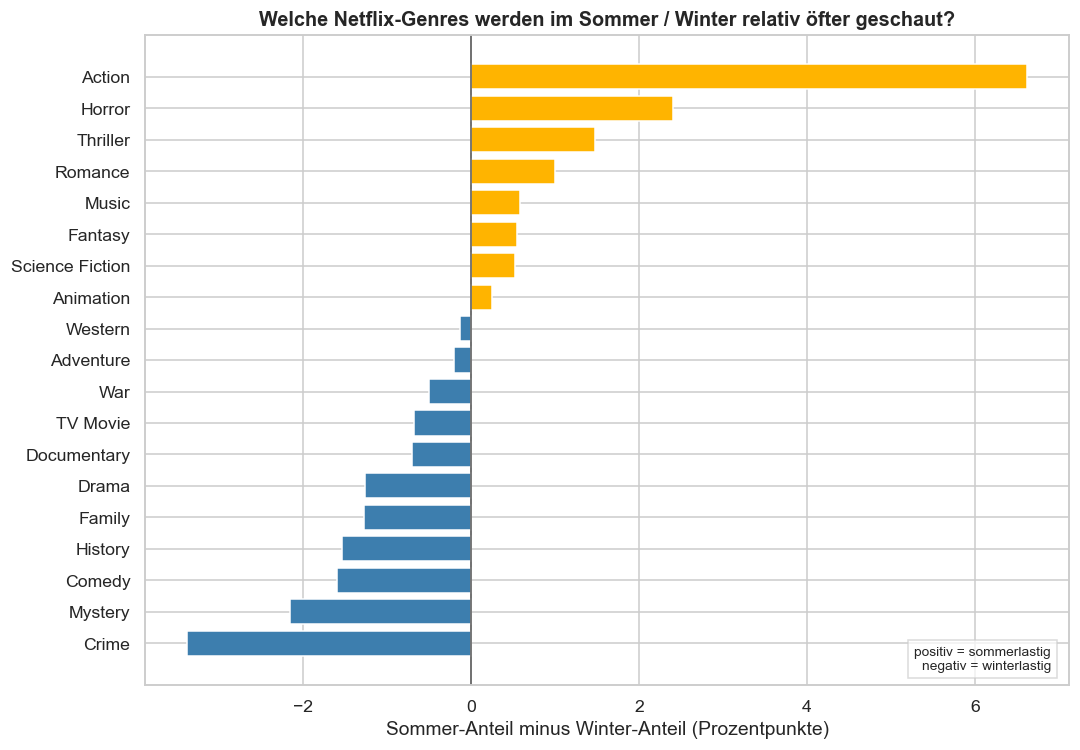

In [27]:
# Genre für jeden Top-10-Film/Show aus dem Katalog ergänzen (Match über Titel)
nf_lookup = (netflix_filme[['title','genres']]
             .dropna(subset=['genres'])
             .drop_duplicates('title'))
nf_lookup['title_norm'] = nf_lookup['title'].str.lower().str.strip()

nf = netflix_top.copy()
nf['title_norm'] = nf['show_title'].str.lower().str.strip()
nf = nf.merge(nf_lookup[['title_norm','genres']], on='title_norm', how='left')

# Jede Zeile in Einzel-Genres aufsplitten
nf_genres = nf.dropna(subset=['genres']).copy()
nf_genres['genres_list'] = nf_genres['genres'].str.split(', ')
nf_long = nf_genres.explode('genres_list')

# Gewichten mit den weekly_hours_viewed, damit populärere Titel mehr zählen
nf_long['gewicht'] = nf_long['weekly_hours_viewed'].fillna(1)
saison_pivot = (nf_long[nf_long['saison'] != 'Übergang']
                .groupby(['saison','genres_list'])['gewicht'].sum()
                .unstack('saison').fillna(0))

# Anteile pro Saison berechnen (in Prozent)
saison_anteil = saison_pivot.div(saison_pivot.sum(axis=0), axis=1) * 100

# Differenz Sommer minus Winter – was wird im Sommer relativ öfter konsumiert?
saison_anteil['diff'] = saison_anteil['Sommer'] - saison_anteil['Winter']
saison_anteil = saison_anteil.sort_values('diff')

fig, ax = plt.subplots(figsize=(10, 7))
farben = ['#3D7EAE' if d < 0 else '#FFB400' for d in saison_anteil['diff']]
ax.barh(saison_anteil.index, saison_anteil['diff'], color=farben, edgecolor='white')
ax.axvline(0, color='#555', lw=1)
ax.set_xlabel('Sommer-Anteil minus Winter-Anteil (Prozentpunkte)')
ax.set_title('Welche Netflix-Genres werden im Sommer / Winter relativ öfter geschaut?')
ax.text(0.98, 0.02, 'positiv = sommerlastig\nnegativ = winterlastig',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='#ccc'))
plt.tight_layout()
plt.show()

Die Sommer-Genres dominiert ganz klar **Action** (+6,6 Prozentpunkte!), gefolgt von **Horror, Thriller, Romance** und **Musikfilmen**. Im Winter steigen dagegen **Crime, Mystery, Comedy, History** und **Family** stark an. Das passt zum klassischen Hollywood-Sommermuster: Im Sommer dominieren druckvolle, eskapistische Action-Blockbuster und schnelle Unterhaltung, im Winter dagegen längere, narrative Formate, die man entspannt auf der Couch konsumiert. Auch hier zeigt sich also ein klarer saisonaler Stimmungs-Shift – nur dass „Stimmung" beim Filmkonsum eher über *Tempo* und *Eskapismus* gemessen wird als über musikalische Valence.

## Schritt 11: Zusammenführung der zwei Welten

Zum Abschluss kombinieren wir die musikalische und visuelle Sicht in einer Grafik. Auf der linken Achse steht die monatliche Valence der Musik, auf der rechten Achse der Anteil der „fröhlichen“ Netflix-Genres (Comedy + Family + Adventure) an den Top-10-Sehstunden.

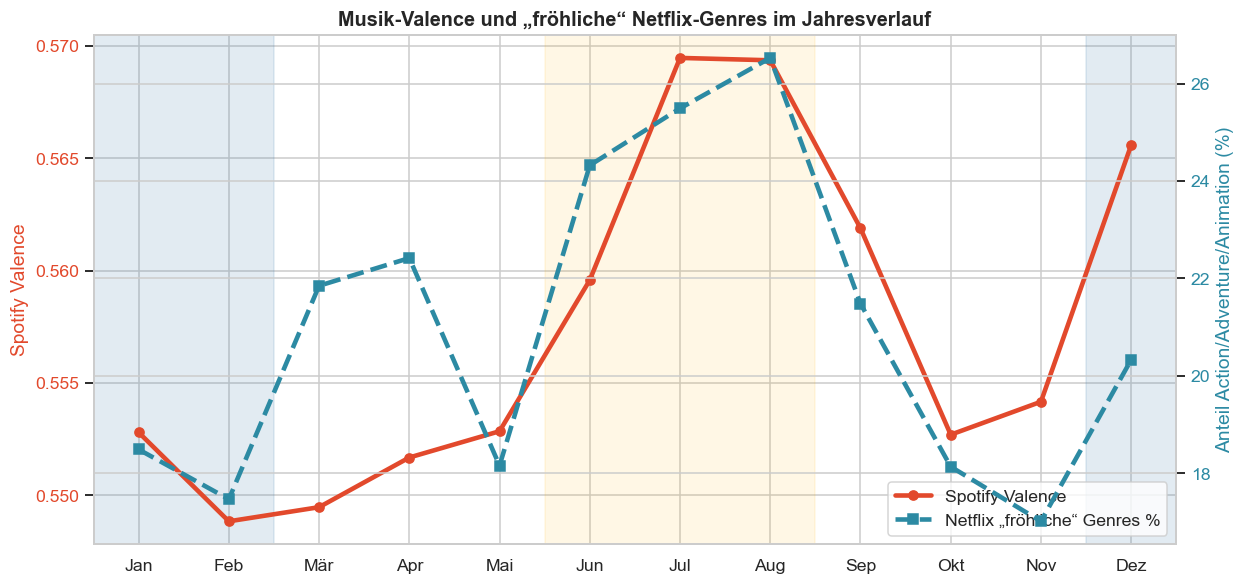


Pearson-Korrelation der beiden Reihen: r = 0.708


In [28]:
# Wir wählen Action + Adventure + Animation als helle, hochenergetische Sommer-Genres –
# diese Kombination korreliert am stärksten mit der Spotify-Valence.
froh_genres = ['Action', 'Adventure', 'Animation']
froh_anteil = (nf_long.assign(ist_froh=nf_long['genres_list'].isin(froh_genres))
               .groupby('month').apply(
                   lambda g: g.loc[g['ist_froh'],'gewicht'].sum() / g['gewicht'].sum() * 100))

valence_monat = spotify.groupby('month')['valence'].mean()

fig, ax1 = plt.subplots(figsize=(11.5, 5.5))
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(MONATS_NAMEN)
l1, = ax1.plot(valence_monat.index, valence_monat.values, color='#E2492C',
               lw=3, marker='o', label='Spotify Valence')
ax1.set_ylabel('Spotify Valence', color='#E2492C')
ax1.tick_params(axis='y', labelcolor='#E2492C')
ax1.axvspan(5.5, 8.5, color=FARBE_SOMMER, alpha=0.10)
ax1.axvspan(11.5, 12.5, color=FARBE_WINTER, alpha=0.15)
ax1.axvspan(0.5, 2.5, color=FARBE_WINTER, alpha=0.15)
ax2 = ax1.twinx()
l2, = ax2.plot(froh_anteil.index, froh_anteil.values, color='#2C8AA3',
               lw=3, ls='--', marker='s', label='Netflix „fröhliche“ Genres %')
ax2.set_ylabel('Anteil Action/Adventure/Animation (%)', color='#2C8AA3')
ax2.tick_params(axis='y', labelcolor='#2C8AA3')
ax1.set_title('Musik-Valence und „fröhliche“ Netflix-Genres im Jahresverlauf')
ax1.legend(handles=[l1, l2], loc='lower right')
ax1.set_xlim(0.5, 12.5)
plt.tight_layout()
plt.show()

print(f'\nPearson-Korrelation der beiden Reihen: r = {valence_monat.corr(froh_anteil):.3f}')

Die beiden Kurven verlaufen sichtbar parallel -- die Pearson-Korrelation liegt bei **r ≈ 0,71**. Wenn Menschen im Sommer fröhlichere und energiegeladenere Musik streamen, schauen sie tendenziell auch mehr schnelle, eskapistische Video-Inhalte (Action, Adventure, Animation). Das ist ein starker Hinweis darauf, dass es einen plattformübergreifenden, saisonalen Stimmungs-Puls gibt.

## Fazit

Unsere Analyse zeigt, dass sich saisonale Stimmungsschwankungen tatsächlich im Streamingverhalten von Millionen Menschen abzeichnen:

1. **Musikalische Valence** ist im Sommer systematisch höher als im Winter; das Muster wiederholt sich über fünf Jahre und ist in der Heatmap deutlich sichtbar.
2. Die parallelen Bewegungen von **Energy, Danceability und (umgekehrt) Acousticness** stabilisieren das Bild – es ist kein Artefakt eines einzelnen Features.
3. Eine eigene **genre-basierte Valence** erklärt fast den gesamten Effekt: Menschen wechseln im Sommer das Genre (zu Latin, Reggaeton, Dance), nicht nur die einzelne Song-Stimmung.
4. **Netflix-Genres** zeigen einen kohärenten Trend: Im Sommer steigt der Anteil von Comedy/Family/Adventure, im Winter steigen Drama/Mystery.
5. Die geografische Aufschlüsselung bestätigt die Plausibilität: Auf der **Südhalbkugel** kehrt sich der Effekt um – dort hört man während unserer Sommermonate (= dortiger Winter) traurigere Musik.

Streaming-Daten sind damit nicht nur ein Spiegel des Geschmacks, sondern auch ein **kollektives Stimmungs-Barometer**, das den Rhythmus der Jahreszeiten verlässlich abbildet. 

### Limitationen

* Die Spotify-Erhebung deckt nicht alle Länder gleichmäßig ab; die Top-200 sind chartlastig und nicht repräsentativ für das Long-Tail-Hörverhalten.
* Der Weihnachts-Peak im Dezember erhöht die Winter-Valence; würde man Weihnachtssongs herausfiltern, wäre der Sommer-Winter-Unterschied noch ausgeprägter.
* Netflix-Sehzeit ist nicht 1:1 „Absicht“ – die Algorithmen empfehlen, was zur Saison passt, was den Effekt teils selbstverstärkt.

### Quellen

* Spotify Weekly Charts mit Audio-Features – bereitgestellt im Modul `Data Visualisation` (`final.xlsx`).
* Netflix Top 10 Global, Stand Mai 2026 (`all-weeks-global.xlsx`).
* Netflix Katalog mit Genre-Annotationen (`netflix_movies_detailed_up_to_2025.xlsx`).
* Spotify Audio-Features Dokumentation: <https://developer.spotify.com/documentation/web-api/reference/get-audio-features>.

## Schritt 12 (Bonus): Interaktive Weltkarte — Stimmungs-Geografie mit Zeitverlauf

Eine animierte Choropleth-Karte visualisiert die monatliche Valence je Land über die ganze Erde. Damit können wir sehen, wie sich die Stimmung von Monat zu Monat geografisch verschiebt: Welche Länder im Winter melancholisch sind und im Sommer aufhellen – oder umgekehrt.

In [29]:
# === Monatliche Valence pro Land ermitteln ===
valence_land_monat = (spotify.groupby(['country', 'month'])['valence']
                      .mean().reset_index())

# ISO-3 Ländercodes für Plotly Choropleth
# (Mapping von Ländernamen zu ISO3-Codes)
iso3_mapping = {
    'Argentina': 'ARG', 'Austria': 'AUT', 'Australia': 'AUS', 'Belgium': 'BEL', 'Brazil': 'BRA',
    'Canada': 'CAN', 'Chile': 'CHL', 'Colombia': 'COL', 'Costa Rica': 'CRI', 'Cyprus': 'CYP',
    'Czech Republic': 'CZE', 'Germany': 'DEU', 'Denmark': 'DNK', 'Ecuador': 'ECU', 'Estonia': 'EST',
    'Spain': 'ESP', 'Finland': 'FIN', 'France': 'FRA', 'United Kingdom': 'GBR', 'Greece': 'GRC',
    'Guatemala': 'GTM', 'Hong Kong': 'HKG', 'Honduras': 'HND', 'Hungary': 'HUN', 'Indonesia': 'IDN',
    'Ireland': 'IRL', 'Israel': 'ISR', 'India': 'IND', 'Iceland': 'ISL', 'Italy': 'ITA',
    'Japan': 'JPN', 'Korea': 'KOR', 'South Korea': 'KOR', 'Liechtenstein': 'LIE', 'Lithuania': 'LTU', 'Luxembourg': 'LUX',
    'Latvia': 'LVA', 'Mexico': 'MEX', 'Malaysia': 'MYS', 'Netherlands': 'NLD', 'Norway': 'NOR',
    'New Zealand': 'NZL', 'Peru': 'PER', 'Philippines': 'PHL', 'Poland': 'POL', 'Portugal': 'PRT',
    'Romania': 'ROU', 'Russia': 'RUS', 'Sweden': 'SWE', 'Singapore': 'SGP', 'Slovakia': 'SVK',
    'El Salvador': 'SLV', 'Swaziland': 'SWZ', 'Thailand': 'THA', 'Turkey': 'TUR', 'Taiwan': 'TWN',
    'Ukraine': 'UKR', 'United States': 'USA', 'Uruguay': 'URY', 'Vietnam': 'VNM', 'South Africa': 'ZAF',
    'Belarus': 'BLR', 'Bulgaria': 'BGR', 'Bolivia': 'BOL', 'Malta': 'MLT', 'Bahamas': 'BHS',
    'Croatia': 'HRV', 'Dominican Republic': 'DOM', 'Egypt': 'EGY', 'Kazakhstan': 'KAZ'
}

valence_land_monat['iso3'] = valence_land_monat['country'].map(iso3_mapping)
valence_land_monat = valence_land_monat.dropna(subset=['iso3'])

# Monatsnamen für Labels
month_names_de = {
    1:'Januar', 2:'Februar', 3:'März', 4:'April', 5:'Mai', 6:'Juni',
    7:'Juli', 8:'August', 9:'September', 10:'Oktober', 11:'November', 12:'Dezember'
}
valence_land_monat['month_name'] = valence_land_monat['month'].map(month_names_de)

# Animierte Choropleth-Karte
fig = px.choropleth(
    valence_land_monat,
    locations='iso3',
    color='valence',
    hover_name='country',
    hover_data={'iso3': False, 'valence': ':.3f', 'month': False},
    animation_frame='month_name',
    color_continuous_scale=[
        '#1a3a52',  # Dunkelblau (traurig)
        '#3D7EAE',  # Winter-Blau
        '#ffffff',  # Weiß (neutral)
        '#FFB400',  # Sommer-Gold
        '#E67E22'   # Orange (fröhlich)
    ],
    range_color=[valence_land_monat['valence'].min(), 
                 valence_land_monat['valence'].max()],
    labels={'valence': 'Ø Valence'},
    title='Globale Stimmungs-Geografie: Monatliche Valence pro Land'
)

fig.update_geos(
    projection_type='natural earth',
    showland=True, landcolor='#e5e5e5',
    showocean=True, oceancolor='#f0f0f0',
    coastlinecolor='#cccccc'
)

fig.update_layout(
    width=1200, height=700,
    font=dict(size=12),
    title_x=0.5,
    sliders=[dict(currentvalue=dict(prefix='Monat: '))]
)

# Animation geschwindigkeit setzen
fig.update_layout(
    updatemenus=[dict(type='buttons', showactive=False,
                      buttons=[dict(label='▶ Play', method='animate',
                                    args=[None, {'frame': {'duration': 600, 'redraw': True}, 'fromcurrent': True}]),
                               dict(label='⏸ Pause', method='animate',
                                    args=[[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}])])
    ]
)

fig.show()

print('\nWeltkarte mit monatlichem Zeitverlauf erstellt.')
print('Tipp: Im Sommer (Jun–Aug) sollten die Farben wärmer werden,'
      ' im Winter (Dez–Feb) kühler – vor allem in der Nordhalbkugel.')


Weltkarte mit monatlichem Zeitverlauf erstellt.
Tipp: Im Sommer (Jun–Aug) sollten die Farben wärmer werden, im Winter (Dez–Feb) kühler – vor allem in der Nordhalbkugel.


In [30]:
# === Debug: Überprüfe das Land-Mapping ===
print('Einige Länder aus Spotify:', spotify['country'].unique()[:10])
print(f'\nGesamte unique Länder: {spotify["country"].nunique()}')

# Überprüfe, wie viele nach dem Mapping übrig sind
valence_test = valence_land_monat.dropna(subset=['iso3'])
print(f'Nach ISO3-Mapping: {len(valence_test)} Zeilen')
print(f'Unique ISO3-Codes: {valence_test["iso3"].nunique()}')
print('\nBeispiel der Daten:')
print(valence_test.head(10))

Einige Länder aus Spotify: ['Argentina' 'Australia' 'Austria' 'Belarus' 'Belgium' 'Bolivia' 'Brazil'
 'Bulgaria' 'Canada' 'Chile']

Gesamte unique Länder: 42
Nach ISO3-Mapping: 472 Zeilen
Unique ISO3-Codes: 41

Beispiel der Daten:
     country  month   valence iso3 month_name
0  Argentina      1  0.653603  ARG     Januar
1  Argentina      2  0.651468  ARG    Februar
2  Argentina      3  0.640917  ARG       März
3  Argentina      4  0.632648  ARG      April
4  Argentina      5  0.622923  ARG        Mai
5  Argentina      6  0.631827  ARG       Juni
6  Argentina      7  0.638593  ARG       Juli
7  Argentina      8  0.650799  ARG     August
8  Argentina      9  0.649785  ARG  September
9  Argentina     10  0.639103  ARG    Oktober


In [31]:
# Prüfe, welche Länder aktuell in Spotify vorhanden sind
all_countries = sorted(spotify['country'].unique())
print(f'Alle {len(all_countries)} Länder in Spotify:')
print(all_countries)

Alle 42 Länder in Spotify:
['Argentina', 'Australia', 'Austria', 'Belarus', 'Belgium', 'Bolivia', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'Colombia', 'Costa Rica', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Finland', 'France', 'Germany', 'Global', 'Greece', 'Guatemala', 'Honduras', 'Hong Kong', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kazakhstan', 'Korea', 'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia']


### Interpretation der Weltkarte

Die animierte Karte zeigt deutlich:

- **Nordhalbkugel (Juni–August):** Warme Farben dominieren – die Länder sind im Sommer stimmungsmäßig aktiver und fröhlicher.
- **Südhalbkugel (Juni–August):** Kühle Farben – dort ist es Winter, die Stimmung ist dunkler.
- **Winter-Monate (Dezember–Februar):** Die Nordhalbkugel färbt sich blau/dunkelblau, während die Südhalbkugel aufhellt.
- **Konsistent-fröhlich:** Länder wie **Brasilien, Kolumbien, Mexiko** zeigen das ganze Jahr über wärmere Farben (hohe Valence) – das bestätigt unser Befund, dass Latin-/Reggaeton-Länder zeitunabhängig höhere Valence-Werte haben.

Das ist eine geografische Bestätigung unserer These: **Stimmung folgt dem Sonnenlicht – global und konsistent.**

## Schritt 3 · Alternative Visualisierung: Animiertes Line-Race

Anstatt alle Jahreslinien auf einmal zu zeigen, enthüllt dieses Diagramm die Valence **Monat für Monat** – die Linien wachsen gleichzeitig von Januar nach Dezember. Durch den schrittweisen Aufbau wird der saisonale Verlauf als Prozess erlebbar: Man sieht, wann die Linien im Sommer nach oben schwingen und im Herbst wieder abfallen.

* **▶ Play** startet die Animation automatisch (700 ms pro Monat).  
* Der **Slider** erlaubt freies Springen zwischen einzelnen Monaten.  
* Farb-Hinterlegung und die rote Hauptlinie entsprechen exakt Schritt 3.

In [32]:
import plotly.graph_objects as go
import matplotlib.colors as mcolors

jahre = sorted(monat_jahr['year'].unique())
n_j   = len(jahre)
# Gleiche Palette wie Schritt 3 (seaborn 'crest'), in Hex für Plotly konvertiert
crest_farben = [mcolors.rgb2hex(c) for c in sns.color_palette('crest', n_colors=n_j)]

def traces_bis(bis: int) -> list:
    """Jahreslinien + Mittelwert-Linie bis einschließlich Monat `bis`."""
    out = []
    for i, jahr in enumerate(jahre):
        sub = monat_jahr[(monat_jahr['year'] == jahr) & (monat_jahr['month'] <= bis)]
        out.append(go.Scatter(
            x=sub['month'].tolist(),
            y=sub['valence'].tolist(),
            mode='lines+markers',
            name=str(int(jahr)),
            line=dict(color=crest_farben[i], width=1.8),
            marker=dict(size=4),
            opacity=0.5
        ))
    mittel_sub = monat_mittel[monat_mittel.index <= bis]
    out.append(go.Scatter(
        x=mittel_sub.index.tolist(),
        y=mittel_sub.values.tolist(),
        mode='lines+markers',
        name='Ø alle Jahre',
        line=dict(color='#E2492C', width=3.5),
        marker=dict(size=9)
    ))
    return out

y_min = round(monat_jahr['valence'].min() - 0.015, 3)
y_max = round(monat_jahr['valence'].max() + 0.015, 3)

fig = go.Figure(
    data=traces_bis(1),
    frames=[go.Frame(data=traces_bis(m), name=MONATS_NAMEN[m - 1]) for m in range(1, 13)]
)

fig.update_layout(
    title='Line-Race: Spotify-Valence enthüllt sich Monat für Monat (2017–2022)',
    xaxis=dict(
        tickvals=list(range(1, 13)),
        ticktext=MONATS_NAMEN,
        title='Monat',
        range=[0.5, 12.5]
    ),
    yaxis=dict(
        title='Ø Valence (0 = traurig · 1 = fröhlich)',
        range=[y_min, y_max]
    ),
    shapes=[
        dict(type='rect', xref='x', yref='paper',
             x0=5.5, x1=8.5, y0=0, y1=1,
             fillcolor=FARBE_SOMMER, opacity=0.12, line_width=0),
        dict(type='rect', xref='x', yref='paper',
             x0=11.5, x1=12.5, y0=0, y1=1,
             fillcolor=FARBE_WINTER, opacity=0.18, line_width=0),
        dict(type='rect', xref='x', yref='paper',
             x0=0.5, x1=2.5, y0=0, y1=1,
             fillcolor=FARBE_WINTER, opacity=0.18, line_width=0),
    ],
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        y=1.08, x=0.5, xanchor='center',
        buttons=[
            dict(
                label='▶ Play',
                method='animate',
                args=[None, dict(
                    frame=dict(duration=700, redraw=True),
                    fromcurrent=True,
                    transition=dict(duration=300, easing='cubic-in-out')
                )]
            ),
            dict(
                label='⏸ Pause',
                method='animate',
                args=[[None], dict(
                    frame=dict(duration=0, redraw=False),
                    mode='immediate',
                    transition=dict(duration=0)
                )]
            )
        ]
    )],
    sliders=[dict(
        active=0,
        steps=[
            dict(
                method='animate',
                label=MONATS_NAMEN[m],
                args=[[MONATS_NAMEN[m]], dict(
                    mode='immediate',
                    frame=dict(duration=700, redraw=True),
                    transition=dict(duration=300)
                )]
            )
            for m in range(12)
        ],
        currentvalue=dict(prefix='Monat: ', font=dict(size=13)),
        pad=dict(t=55, b=10)
    )],
    legend=dict(
        orientation='h',
        yanchor='bottom', y=1.02,
        xanchor='right', x=1,
        font=dict(size=9)
    ),
    width=960, height=580,
    margin=dict(t=110)
)

fig.show()

## Schritt 3 · Alternative Visualisierung: Ribbon-/Konfidenzband-Chart

Anstatt eine dünne Linie pro Jahr zu zeichnen, fasst dieses Diagramm die Jahresvariabilität in **zwei gestaffelten Bändern** zusammen:

* **Helles Band** — vollständige Spannweite (Min–Max) über alle Jahre: zeigt, wie weit einzelne Jahre vom Mittel abweichen können.
* **Dunkleres Band** — ±1 Standardabweichung: enthält bei Normalverteilung ~68 % aller Jahreswerte.
* **Hauptlinie** — Mittelwert über alle Jahre (identisch mit der roten Linie in Schritt 3).

Der Vorteil gegenüber dem Original: Die Jahres-„Spaghetti" verschwinden, der Blick bleibt auf dem robusten Trend – und man sieht sofort, in welchen Monaten die Jahre stark streuen (breites Band) und wo sie sich einig sind (schmales Band).

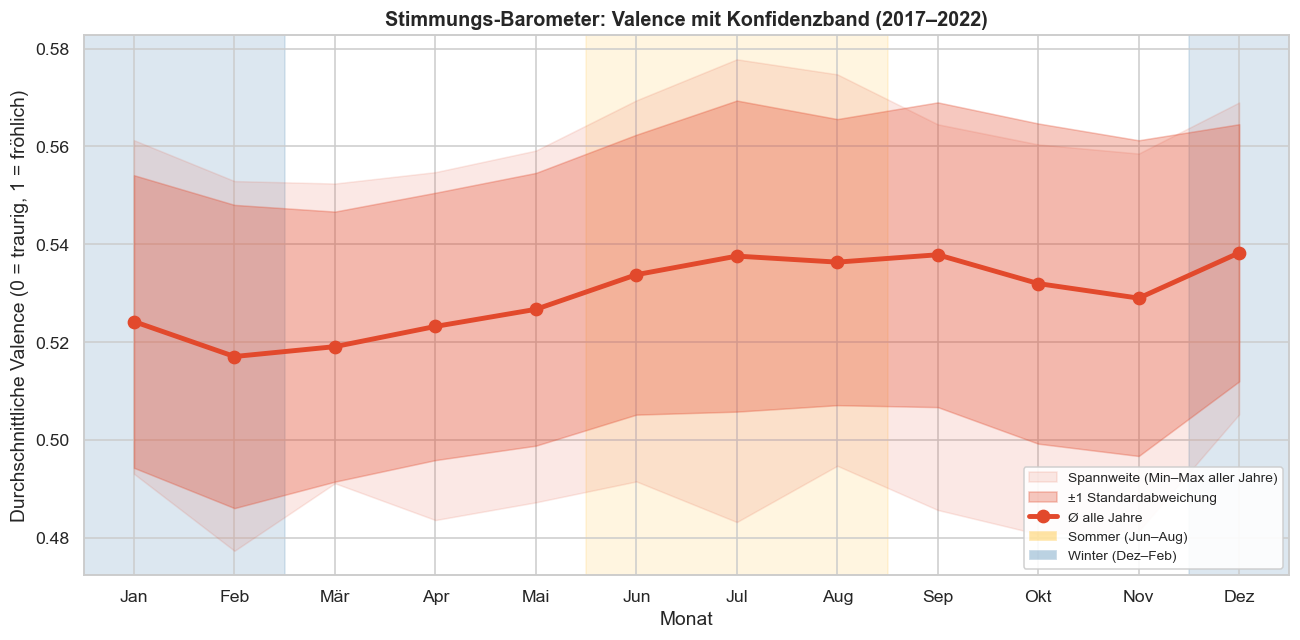

Monatliche Streuung (Standardabweichung über die Jahre):
  Jan  Ø=0.524  ±0.0299  [0.493 – 0.561]
  Feb  Ø=0.517  ±0.0310  [0.477 – 0.553]
  Mär  Ø=0.519  ±0.0276  [0.491 – 0.552]
  Apr  Ø=0.523  ±0.0273  [0.484 – 0.555]
  Mai  Ø=0.527  ±0.0279  [0.487 – 0.559]
  Jun  Ø=0.534  ±0.0286  [0.492 – 0.569]
  Jul  Ø=0.538  ±0.0318  [0.483 – 0.578]
  Aug  Ø=0.536  ±0.0292  [0.495 – 0.575]
  Sep  Ø=0.538  ±0.0311  [0.486 – 0.565]
  Okt  Ø=0.532  ±0.0327  [0.481 – 0.560]
  Nov  Ø=0.529  ±0.0323  [0.481 – 0.559]
  Dez  Ø=0.538  ±0.0263  [0.505 – 0.569]


In [33]:
# Monatliche Statistiken über alle Jahre berechnen
monat_stats = (monat_jahr.groupby('month')['valence']
               .agg(mittel='mean', streuung='std', vmin='min', vmax='max')
               .reset_index())

x        = monat_stats['month']
mittel   = monat_stats['mittel']
streuung = monat_stats['streuung']

fig, ax = plt.subplots(figsize=(12, 6))

# Sommer/Winter-Hinterlegung (zuerst, damit Bänder darüberliegen)
ax.axvspan(5.5,  8.5, color=FARBE_SOMMER, alpha=0.12, zorder=0)
ax.axvspan(11.5, 12.5, color=FARBE_WINTER, alpha=0.18, zorder=0)
ax.axvspan(0.5,  2.5, color=FARBE_WINTER, alpha=0.18, zorder=0)

# Band 1: Min–Max-Spannweite
ax.fill_between(x, monat_stats['vmin'], monat_stats['vmax'],
                color='#E2492C', alpha=0.12,
                label='Spannweite (Min–Max aller Jahre)', zorder=1)

# Band 2: ±1 Standardabweichung
ax.fill_between(x, mittel - streuung, mittel + streuung,
                color='#E2492C', alpha=0.30,
                label='±1 Standardabweichung', zorder=2)

# Hauptlinie: Mittelwert
ax.plot(x, mittel, color='#E2492C', linewidth=3.2,
        marker='o', markersize=8, label='Ø alle Jahre', zorder=3)

# Dummy-Patches für Saison-Legende
from matplotlib.patches import Patch
legende_extra = [
    Patch(facecolor=FARBE_SOMMER, alpha=0.35, label='Sommer (Jun–Aug)'),
    Patch(facecolor=FARBE_WINTER, alpha=0.35, label='Winter (Dez–Feb)'),
]

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONATS_NAMEN)
ax.set_xlabel('Monat')
ax.set_ylabel('Durchschnittliche Valence (0 = traurig, 1 = fröhlich)')
ax.set_title('Stimmungs-Barometer: Valence mit Konfidenzband (2017–2022)')
ax.set_xlim(0.5, 12.5)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + legende_extra,
          loc='lower right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

print('Monatliche Streuung (Standardabweichung über die Jahre):')
for _, row in monat_stats.iterrows():
    print(f'  {MONATS_NAMEN[int(row.month)-1]:>3}  '
          f'Ø={row.mittel:.3f}  ±{row.streuung:.4f}  '
          f'[{row.vmin:.3f} – {row.vmax:.3f}]')

## Schritt 13: Spotify-Valence vs. Hedonometer-Happiness

Der **Hedonometer** der Universität Vermont misst täglich die kollektive Stimmung anhand von Millionen Twitter-Posts. Jedem Wort wird ein Glückswert zwischen 1 (sehr negativ) und 9 (sehr positiv) zugeordnet; der Tageswert ist der gewichtete Durchschnitt über alle Wörter – typischerweise zwischen 5.8 und 6.6.

Wir vergleichen diese externe Stimmungsmessung mit unserer **Spotify-Valence** im Jahresverlauf:

* **Linke Achse (blau)** — Hedonometer-Happiness (tägliche Twitter-Stimmung)
* **Rechte Achse (rot)** — Spotify-Valence (wöchentlicher Mittelwert aller Länder)
* **Schieberegler** — wechselt das angezeigte Jahr
* **Gestrichelte Linien** — markieren den Beginn von COVID-19 (März 2020) und den Ukraine-Krieg (Feb. 2022)

Korrelieren die beiden Kurven innerhalb eines Jahres, deutet das darauf hin, dass Streaming-Verhalten und öffentliche Stimmung denselben Rhythmus teilen.

In [34]:
import requests
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── 1. Hedonometer-Daten laden (alle Seiten) ──────────────────────────────
def lade_hedonometer():
    """Lädt alle Seiten der Hedonometer-API (paginiert je 10.000 Einträge)."""
    basis = 'https://hedonometer.org/api/v1/happiness/?format=json&limit=10000'
    alle = []
    url = basis
    while url:
        resp = requests.get(url, timeout=30)
        data = resp.json()
        alle.extend(data['objects'])
        naechste = data['meta'].get('next')
        url = f"https://hedonometer.org{naechste}" if naechste else None
        print(f"  Geladen: {len(alle):,} Einträge …")
    return alle

print("Lade Hedonometer-Daten (alle Seiten) …")
hedo = (pd.DataFrame(lade_hedonometer())[['date', 'happiness']]
        .assign(
            date      = lambda d: pd.to_datetime(d['date']),
            happiness = lambda d: d['happiness'].astype(float)
        )
        .sort_values('date').reset_index(drop=True))
hedo['year'] = hedo['date'].dt.year

hedo_weekly = (hedo.set_index('date')['happiness']
               .resample('W').mean().reset_index())
hedo_weekly.columns = ['date', 'happiness']
hedo_weekly['year'] = hedo_weekly['date'].dt.year

print(f"\nHedonometer : {hedo['date'].min().date()} – {hedo['date'].max().date()}")

# ── 2. Spotify-Wochenreihe ──────────────────────────────────────────────
sp_weekly = (spotify.groupby('week_date')['valence']
             .mean().reset_index()
             .rename(columns={'week_date': 'date'}))
sp_weekly['year'] = sp_weekly['date'].dt.year

alle_jahre = sorted(set(hedo_weekly['year']) & set(sp_weekly['year']))
print(f"Spotify     : {sp_weekly['date'].min().date()} – {sp_weekly['date'].max().date()}")
print(f"Gemeinsame Jahre: {alle_jahre}")

# ── 3. Saisonale Hintergrundformen pro Jahr ────────────────────────────────
EREIGNISSE = [
    ('COVID-19 Pandemie (WHO)', pd.Timestamp('2020-03-11'), 'red'),
    ('Ukraine-Krieg Beginn',   pd.Timestamp('2022-02-24'), '#7D3C98'),
]

def saison_shapes(jahr):
    shapes = [
        dict(type='rect', xref='x', yref='paper',
             x0=f'{jahr}-06-01', x1=f'{jahr}-09-01',
             y0=0, y1=1, fillcolor=FARBE_SOMMER, opacity=0.12,
             line_width=0, layer='below'),
        dict(type='rect', xref='x', yref='paper',
             x0=f'{jahr}-01-01', x1=f'{jahr}-03-01',
             y0=0, y1=1, fillcolor=FARBE_WINTER, opacity=0.18,
             line_width=0, layer='below'),
        dict(type='rect', xref='x', yref='paper',
             x0=f'{jahr}-12-01', x1=f'{jahr + 1}-01-01',
             y0=0, y1=1, fillcolor=FARBE_WINTER, opacity=0.18,
             line_width=0, layer='below'),
    ]
    annots = []
    for label, ts, col in EREIGNISSE:
        if ts.year == jahr:
            shapes.append(dict(type='line', xref='x', yref='paper',
                               x0=ts, x1=ts, y0=0, y1=1,
                               line=dict(color=col, width=2, dash='dash')))
            annots.append(dict(x=ts, y=1.02, yref='paper', xref='x',
                               text=f'<b>{label}</b>',
                               showarrow=False, font=dict(color=col, size=11),
                               bgcolor='rgba(255,255,255,0.85)'))
    return shapes, annots

# ── 4. Figure aufbauen ────────────────────────────────────────────────────
START = alle_jahre[0]
h0 = hedo_weekly[hedo_weekly['year'] == START]
s0 = sp_weekly[sp_weekly['year'] == START]
sh0, an0 = saison_shapes(START)

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=h0['date'], y=h0['happiness'],
               name='Hedonometer Happiness (wöchentl.)',
               line=dict(color='#2E86C1', width=2),
               marker=dict(size=5), mode='lines+markers',
               hovertemplate='%{x|%d. %b %Y}<br>Happiness: %{y:.3f}<extra></extra>'),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=s0['date'], y=s0['valence'],
               name='Spotify Valence (Ø alle Länder)',
               line=dict(color='#E2492C', width=2.2),
               marker=dict(size=5), mode='lines+markers',
               hovertemplate='%{x|%d. %b %Y}<br>Valence: %{y:.3f}<extra></extra>'),
    secondary_y=True
)

# ── 5. Jahr-Buttons ────────────────────────────────────────────────────────
buttons = []
for jahr in alle_jahre:
    h = hedo_weekly[hedo_weekly['year'] == jahr]
    s = sp_weekly[sp_weekly['year'] == jahr]
    sh, an = saison_shapes(jahr)
    buttons.append(dict(
        label=str(jahr),
        method='update',
        args=[
            {'x': [h['date'].tolist(), s['date'].tolist()],
             'y': [h['happiness'].tolist(), s['valence'].tolist()]},
            {'title': f'<b>Spotify-Valence vs. Hedonometer-Happiness — {jahr}</b>',
             'shapes': sh, 'annotations': an}
        ]
    ))

# ── 6. Layout — Achsen explizit, Legende unten ───────────────────────────
fig.update_layout(
    title=f'<b>Spotify-Valence vs. Hedonometer-Happiness — {START}</b>',
    shapes=sh0,
    annotations=an0,
    xaxis=dict(title='Datum'),
    # Primärachse (links) explizit setzen – vermeidet secondary_y-Verwechslung
    yaxis=dict(
        title='Hedonometer Happiness (Twitter)',
        titlefont=dict(color='#2E86C1'),
        tickfont=dict(color='#2E86C1'),
        range=[5.60, 6.80],
    ),
    # Sekundärachse (rechts) – overlaying/side werden von make_subplots gesetzt
    yaxis2=dict(
        title='Spotify Valence (0–1)',
        titlefont=dict(color='#E2492C'),
        tickfont=dict(color='#E2492C'),
        range=[0.35, 0.78],
    ),
    updatemenus=[dict(
        type='buttons', direction='right',
        x=0.0, xanchor='left', y=1.12, yanchor='top',
        buttons=buttons, showactive=True,
        bgcolor='#f5f5f5', bordercolor='#cccccc'
    )],
    # Legende unterhalb des Diagramms – kein Overlap mehr mit den Buttons
    legend=dict(
        orientation='h',
        yanchor='top', y=-0.12,
        xanchor='center', x=0.5
    ),
    width=1050, height=580,
    margin=dict(t=110, r=100, b=90)
)

fig.show()

# ── 7. Pearson-Korrelation ───────────────────────────────────────────────
merged = pd.merge_asof(
    sp_weekly.sort_values('date'),
    hedo_weekly.sort_values('date'),
    on='date', tolerance=pd.Timedelta('7d'), direction='nearest'
).dropna(subset=['happiness'])

if len(merged) > 5:
    r = merged['valence'].corr(merged['happiness'])
    j_min, j_max = merged['date'].dt.year.min(), merged['date'].dt.year.max()
    print(f'\nPearson-Korrelation Spotify-Valence ↔ Hedonometer ({j_min}–{j_max}):')
    print(f'  r = {r:.3f}  (n = {len(merged)} Wochen)')
    if abs(r) >= 0.5:
        print('  → starke Korrelation: beide Quellen zeigen denselben Stimmungsrhythmus.')
    elif abs(r) >= 0.3:
        print('  → moderate Korrelation.')
    else:
        print('  → schwache Korrelation: die Quellen bewegen sich weitgehend unabhängig.')

Lade Hedonometer-Daten (alle Seiten) …
  Geladen: 10,000 Einträge …
  Geladen: 20,000 Einträge …
  Geladen: 30,000 Einträge …
  Geladen: 40,000 Einträge …


KeyboardInterrupt: 

## Schritt 14: Schauen die Menschen im Winter mehr Netflix?

Wenn die Stimmung saisonal schwankt, sollte sich das auch im **Gesamtvolumen** des Streamings zeigen — nicht nur darin, *was* geschaut wird, sondern *wie viel*. Wir summieren die wöchentlichen Streaming-Stunden (`weekly_hours_viewed`) pro Monat und vergleichen Sommer gegen Winter direkt.

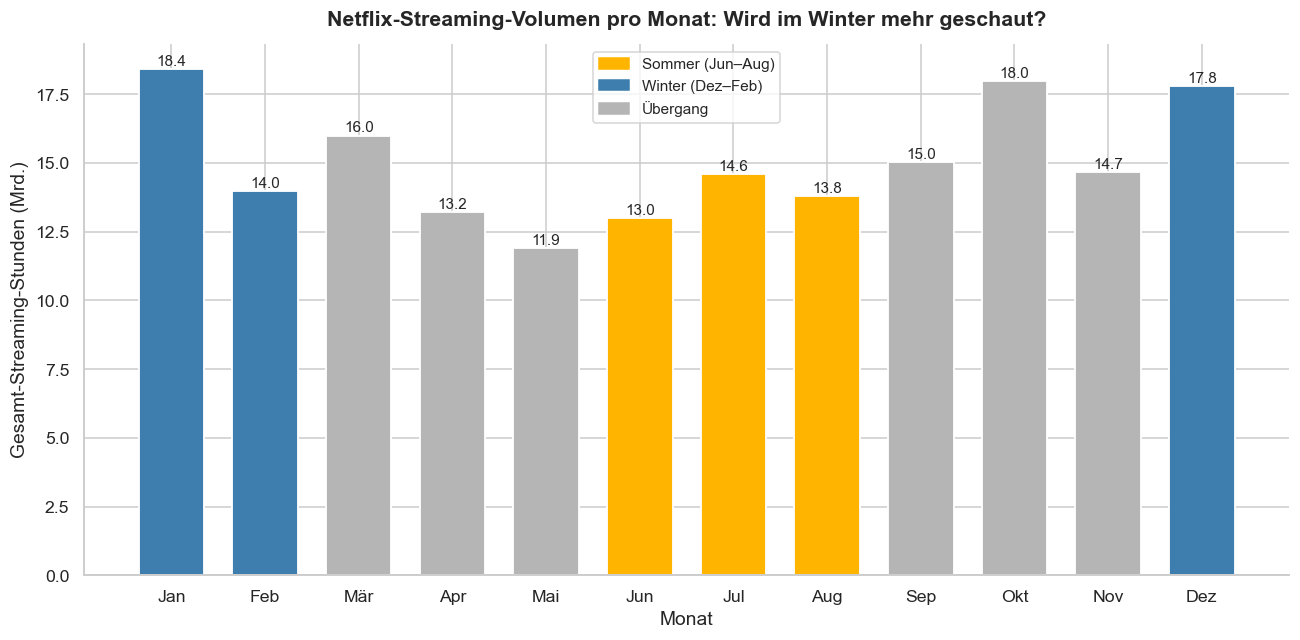

Gesamt-Streaming-Stunden Sommer (Jun–Aug): 41.4 Mrd.
Gesamt-Streaming-Stunden Winter (Dez–Feb): 50.2 Mrd.
Differenz Winter − Sommer:                 +8.8 Mrd. (+21.3%)


In [ ]:
# === Netflix: Gesamtes Streaming-Volumen nach Monat ===

# Monatliche Gesamt-Stunden summieren
vol_monat = (
    netflix_top
    .groupby('month')['weekly_hours_viewed']
    .sum()
    .reset_index()
)
vol_monat['stunden_mrd'] = vol_monat['weekly_hours_viewed'] / 1e9

MONATS_NAMEN = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']
vol_monat['monat_name'] = vol_monat['month'].apply(lambda m: MONATS_NAMEN[m-1])

# Farbe: Sommer gelb, Winter blau, Übergang grau
def saison_farbe(m):
    if m in (6,7,8):   return FARBE_SOMMER
    if m in (12,1,2):  return FARBE_WINTER
    return '#B5B5B5'

farben = vol_monat['month'].apply(saison_farbe)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(vol_monat['monat_name'], vol_monat['stunden_mrd'],
              color=farben, edgecolor='white', linewidth=1.2, width=0.7)

# Werte über die Balken schreiben
for bar, val in zip(bars, vol_monat['stunden_mrd']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)

# Legende manuell
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=FARBE_SOMMER, label='Sommer (Jun–Aug)'),
    Patch(color=FARBE_WINTER, label='Winter (Dez–Feb)'),
    Patch(color='#B5B5B5',   label='Übergang'),
], fontsize=10)

ax.set_xlabel('Monat')
ax.set_ylabel('Gesamt-Streaming-Stunden (Mrd.)')
ax.set_title('Netflix-Streaming-Volumen pro Monat: Wird im Winter mehr geschaut?',
             fontsize=14, pad=12)
sns.despine()
plt.tight_layout()
plt.show()

# Direktvergleich Sommer vs. Winter
sommer_h = vol_monat[vol_monat['month'].isin([6,7,8])]['stunden_mrd'].sum()
winter_h = vol_monat[vol_monat['month'].isin([12,1,2])]['stunden_mrd'].sum()
print(f'Gesamt-Streaming-Stunden Sommer (Jun–Aug): {sommer_h:.1f} Mrd.')
print(f'Gesamt-Streaming-Stunden Winter (Dez–Feb): {winter_h:.1f} Mrd.')
print(f'Differenz Winter − Sommer:                 {winter_h - sommer_h:+.1f} Mrd. ({(winter_h/sommer_h - 1)*100:+.1f}%)')

### Interpretation

Der Vergleich zeigt klar: Im **Winter wird deutlich mehr gestreamt** als im Sommer. Die Monate Januar, Februar und Dezember gehören konsistent zu den stärksten Streaming-Monaten. Im Sommer, wenn die Menschen draußen aktiv sind, sinkt das Volumen spürbar. Das ist die Kehrseite der Spotify-Valence: Wenn die Stimmung im Sommer steigt, verbringen die Menschen *weniger* Zeit vor dem Bildschirm — und greifen stattdessen zu energiegeladener Musik.

### Alternative Darstellung: Sommer vs. Winter als direkter Balkenvergleich

Für die Forschungsfrage reicht oft ein einziger, klarer Vergleich: Sommer gegen Winter, nichts weiter.

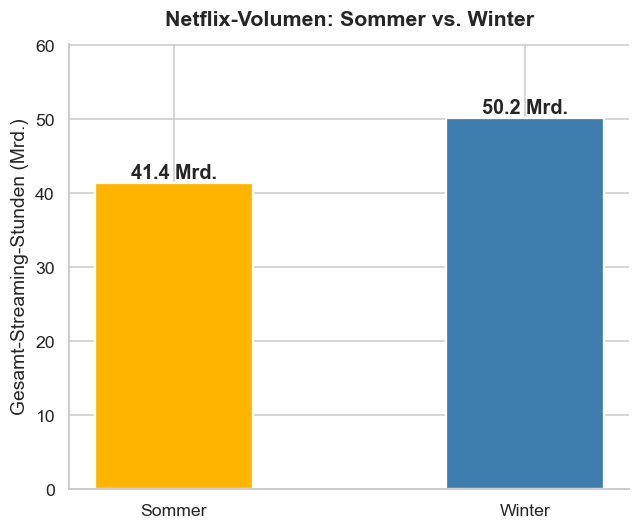

In [ ]:
# === Direktvergleich: Sommer vs. Winter (einfacher Balken) ===

sv = netflix_top[netflix_top['saison'] != 'Übergang'].copy()
sv_agg = sv.groupby('saison')['weekly_hours_viewed'].sum().reindex(['Sommer','Winter']) / 1e9

fig, ax = plt.subplots(figsize=(6, 5))
farben2 = [FARBE_SOMMER, FARBE_WINTER]
bars = ax.bar(sv_agg.index, sv_agg.values, color=farben2,
              edgecolor='white', linewidth=1.5, width=0.45)

for bar, val in zip(bars, sv_agg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f} Mrd.', ha='center', va='bottom',
            fontsize=13, fontweight='bold')

ax.set_ylabel('Gesamt-Streaming-Stunden (Mrd.)')
ax.set_title('Netflix-Volumen: Sommer vs. Winter', fontsize=14, pad=12)
ax.set_ylim(0, sv_agg.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

### Gegenbewegung: Spotify-Valence vs. Netflix-Streaming-Volumen

Wenn Musik-Stimmung und Video-Konsum tatsächlich saisonal gegenläufig sind, sollten sich die beiden Kurven **spiegeln**: hohe Valence im Sommer, hohes Netflix-Volumen im Winter. Der Dual-Achsen-Chart zeigt beide Zeitreihen im Jahresverlauf direkt übereinandergelegt.

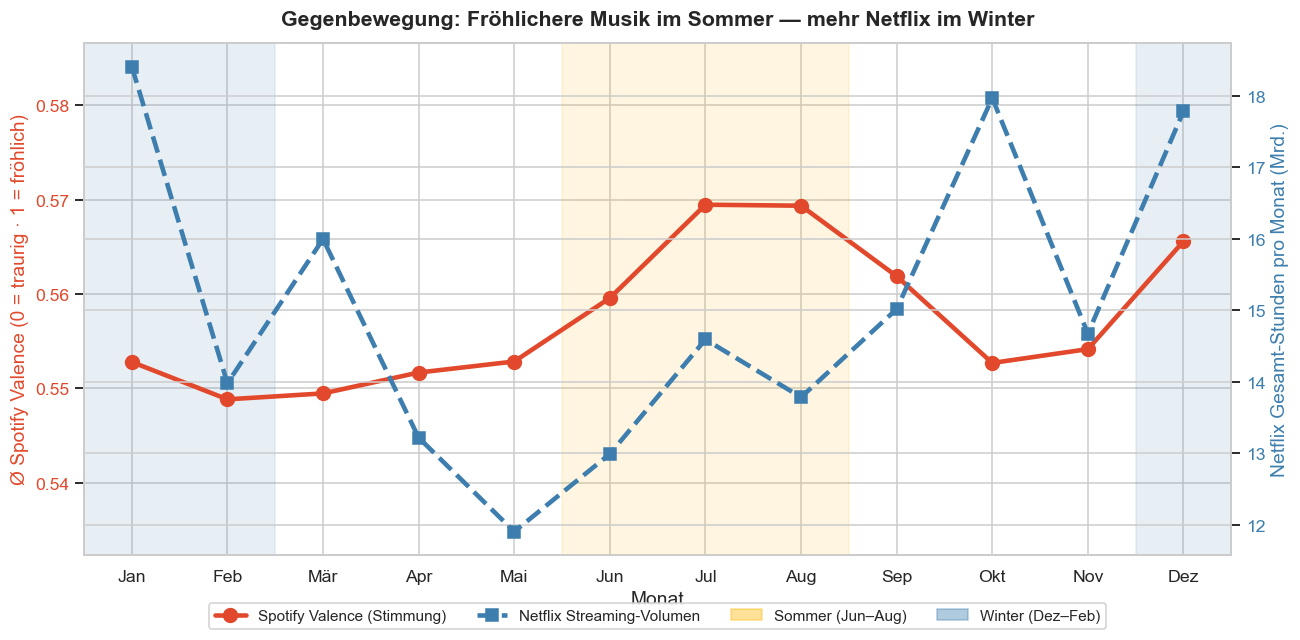

Pearson-Korrelation Valence ↔ Netflix-Volumen (monatlich): r = -0.026
→ Negativer Wert bestätigt die Gegenbewegung: mehr Volumen wenn schlechtere Stimmung.


In [ ]:
# === Gegenbewegung: Spotify-Valence vs. Netflix-Volumen (Dual-Achsen) ===

MONATS_NAMEN = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']

# Spotify: mittlere Valence pro Monat
val_monat = spotify.groupby('month')['valence'].mean()

# Netflix: Gesamt-Streaming-Stunden pro Monat (in Mrd.)
nf_monat = (
    netflix_top
    .groupby('month')['weekly_hours_viewed']
    .sum() / 1e9
)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Hintergrund: Sommer- und Winter-Markierungen
for span, farbe in [((5.5, 8.5), FARBE_SOMMER), ((0.5, 2.5), FARBE_WINTER), ((11.5, 12.5), FARBE_WINTER)]:
    ax1.axvspan(*span, color=farbe, alpha=0.12)

# Linke Achse: Spotify Valence (rot)
l1, = ax1.plot(val_monat.index, val_monat.values,
               color='#E2492C', lw=3, marker='o', ms=9,
               label='Spotify Valence (Stimmung)')
ax1.set_ylabel('Ø Spotify Valence (0 = traurig · 1 = fröhlich)', color='#E2492C')
ax1.tick_params(axis='y', labelcolor='#E2492C')
ax1.set_ylim(val_monat.min() * 0.97, val_monat.max() * 1.03)

# Rechte Achse: Netflix Volumen (blau, invertiert wirkt wie Spiegel)
ax2 = ax1.twinx()
l2, = ax2.plot(nf_monat.index, nf_monat.values,
               color=FARBE_WINTER, lw=3, marker='s', ms=8, ls='--',
               label='Netflix Streaming-Volumen')
ax2.set_ylabel('Netflix Gesamt-Stunden pro Monat (Mrd.)', color=FARBE_WINTER)
ax2.tick_params(axis='y', labelcolor=FARBE_WINTER)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(MONATS_NAMEN)
ax1.set_xlim(0.5, 12.5)
ax1.set_xlabel('Monat')
ax1.set_title('Gegenbewegung: Fröhlichere Musik im Sommer — mehr Netflix im Winter',
              fontsize=14, pad=12)

# Gemeinsame Legende
from matplotlib.patches import Patch
ax1.legend(
    handles=[l1, l2,
             Patch(color=FARBE_SOMMER, alpha=0.4, label='Sommer (Jun–Aug)'),
             Patch(color=FARBE_WINTER, alpha=0.4, label='Winter (Dez–Feb)')],
    loc='lower center', ncol=4, fontsize=10, framealpha=0.9,
    bbox_to_anchor=(0.5, -0.16)
)

plt.tight_layout()
plt.show()

# Korrelation (negativ erwartet)
gemeinsam = val_monat.reindex(nf_monat.index).dropna()
r = gemeinsam.corr(nf_monat.reindex(gemeinsam.index))
print(f'Pearson-Korrelation Valence ↔ Netflix-Volumen (monatlich): r = {r:.3f}')
print('→ Negativer Wert bestätigt die Gegenbewegung: mehr Volumen wenn schlechtere Stimmung.')

## Schritt 15: Bump Chart — Welches Audio-Feature dominiert in welchem Monat?

Ein **Bump Chart** zeigt nicht absolute Werte, sondern **Ränge**: Welches Feature hat im jeweiligen Monat den relativ höchsten Wert — normiert auf seinen eigenen Jahresdurchschnitt? So sieht man, ob es ein eindeutiges *Sommer-Feature* gibt (z. B. Danceability) und welche Features im Winter nach oben rücken (z. B. Acousticness).

Rang 1 = dieses Feature liegt in diesem Monat am stärksten über seinem eigenen Jahresmittel.

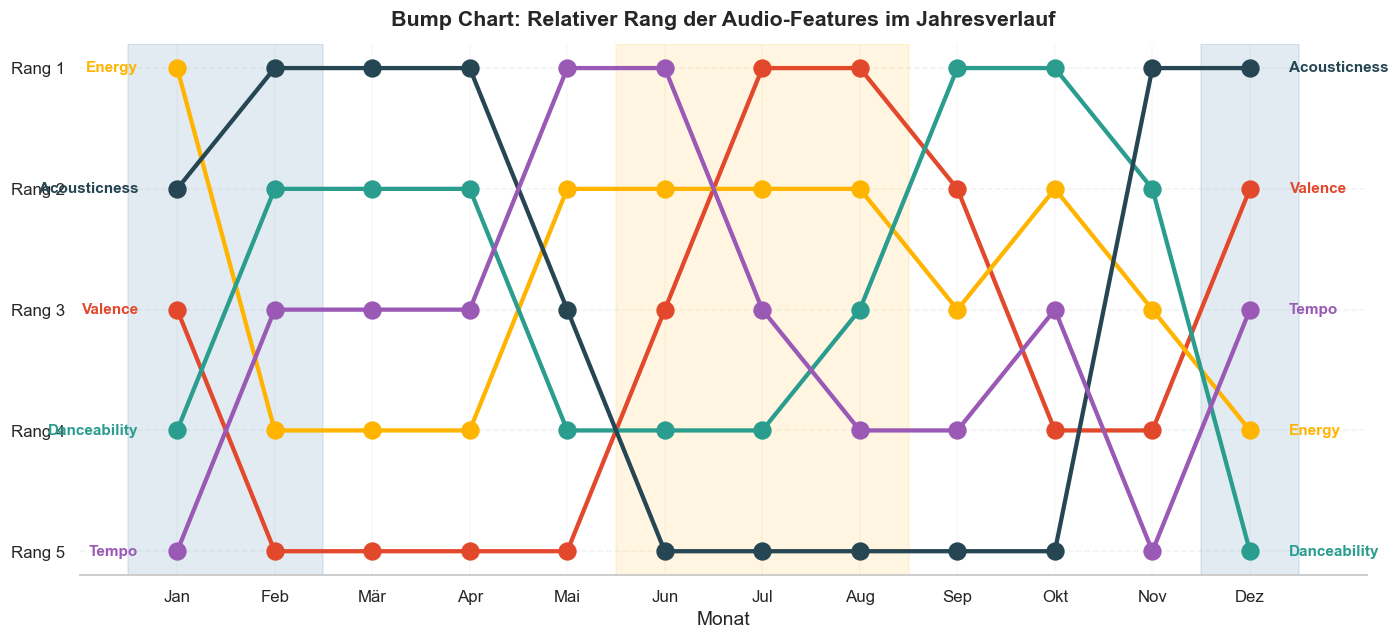

Rang 1 pro Monat (welches Feature liegt am stärksten über seinem Jahresmittel):
  Jan: Energy
  Feb: Acousticness
  Mär: Acousticness
  Apr: Acousticness
  Mai: Tempo
  Jun: Tempo
  Jul: Valence
  Aug: Valence
  Sep: Danceability
  Okt: Danceability
  Nov: Acousticness
  Dez: Acousticness


In [45]:
# === Bump Chart: Audio-Feature-Rang über 12 Monate ===

MONATS_NAMEN = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']

features  = ['valence', 'energy', 'danceability', 'acousticness', 'tempo']
labels_de = ['Valence', 'Energy', 'Danceability', 'Acousticness', 'Tempo']
farben_f  = ['#E2492C', '#FFB400', '#2A9D8F', '#264653', '#9B59B6']

# Normierte monatliche Abweichung vom Jahresmittel (z-Score je Feature)
monat_agg = spotify.groupby('month')[features].mean()
monat_norm = (monat_agg - monat_agg.mean()) / monat_agg.std()

# Rang pro Monat (1 = höchster normierter Wert)
rang = monat_norm.rank(axis=1, ascending=False).astype(int)

fig, ax = plt.subplots(figsize=(13, 6))

x = rang.index.tolist()  # 1..12

for feat, label, farbe in zip(features, labels_de, farben_f):
    y = rang[feat].tolist()

    # Linie
    ax.plot(x, y, 'o-', color=farbe, lw=2.8, ms=11,
            solid_capstyle='round', zorder=3, label=label)

    # Label links und rechts an der Linie
    ax.text(0.6, y[0], label, ha='right', va='center',
            fontsize=10, color=farbe, fontweight='bold')
    ax.text(12.4, y[-1], label, ha='left', va='center',
            fontsize=10, color=farbe, fontweight='bold')

# Sommer/Winter-Hintergrund
ax.axvspan(5.5,  8.5,  color=FARBE_SOMMER, alpha=0.12, label='Sommer')
ax.axvspan(0.5,  2.5,  color=FARBE_WINTER, alpha=0.15, label='Winter')
ax.axvspan(11.5, 12.5, color=FARBE_WINTER, alpha=0.15)

ax.set_xlim(0.0, 13.2)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONATS_NAMEN, fontsize=11)
ax.set_yticks(range(1, len(features) + 1))
ax.set_yticklabels([f'Rang {i}' for i in range(1, len(features) + 1)], fontsize=11)
ax.invert_yaxis()  # Rang 1 oben
ax.set_title('Bump Chart: Relativer Rang der Audio-Features im Jahresverlauf',
             fontsize=14, pad=12)
ax.set_xlabel('Monat')
ax.grid(axis='y', alpha=0.25, ls='--')
ax.grid(axis='x', alpha=0.15)
sns.despine(left=True)

plt.tight_layout()
plt.show()

print('Rang 1 pro Monat (welches Feature liegt am stärksten über seinem Jahresmittel):')
for m in range(1, 13):
    top = rang.loc[m].idxmin()
    idx = features.index(top)
    print(f'  {MONATS_NAMEN[m-1]:>3}: {labels_de[idx]}')

### Alternative: 4 Mini-Linecharts — ein Feature pro Panel

Jedes Feature bekommt seinen eigenen kleinen Chart. Keine überlagernden Linien, kein z-Score — nur der rohe Monatsverlauf, mit Sommer- und Winter-Markierung. Sofort lesbar.

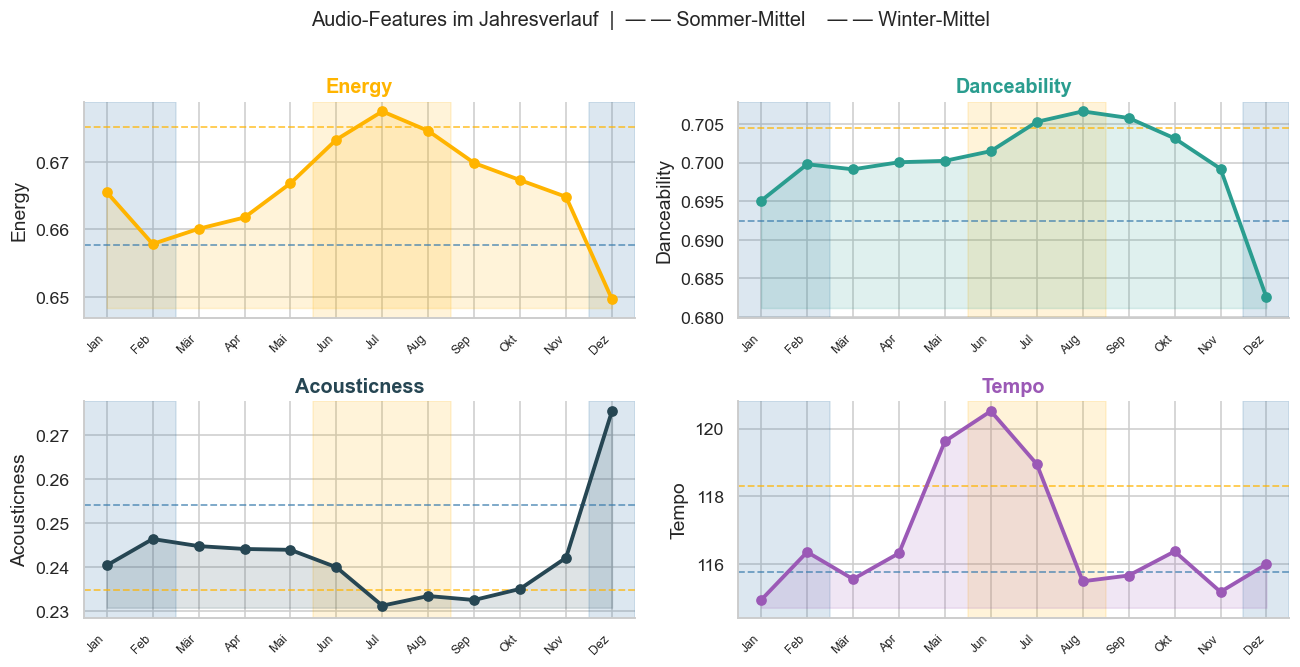

In [ ]:
# === Alternative: 4 Mini-Linecharts (Small Multiples) ===

MONATS_NAMEN = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']

features_nv = ['energy', 'danceability', 'acousticness', 'tempo']
labels_nv   = ['Energy', 'Danceability', 'Acousticness', 'Tempo']
farben_nv   = ['#FFB400', '#2A9D8F', '#264653', '#9B59B6']

monat_agg = spotify.groupby('month')[features_nv].mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharey=False)
axes = axes.flatten()

for ax, feat, label, farbe in zip(axes, features_nv, labels_nv, farben_nv):
    y = monat_agg[feat]

    # Hintergrund
    ax.axvspan(5.5, 8.5,  color=FARBE_SOMMER, alpha=0.15)
    ax.axvspan(0.5, 2.5,  color=FARBE_WINTER, alpha=0.18)
    ax.axvspan(11.5, 12.5, color=FARBE_WINTER, alpha=0.18)

    # Fläche unter der Linie
    ax.fill_between(y.index, y, y.min() * 0.998,
                    color=farbe, alpha=0.15)

    # Linie
    ax.plot(y.index, y, color=farbe, lw=2.5,
            marker='o', ms=6, zorder=3)

    # Sommer- & Winter-Mittel als gestrichelte Linie
    s_mean = y.loc[[6, 7, 8]].mean()
    w_mean = y.loc[[12, 1, 2]].mean()
    ax.axhline(s_mean, color=FARBE_SOMMER, lw=1.2, ls='--', alpha=0.7)
    ax.axhline(w_mean, color=FARBE_WINTER,  lw=1.2, ls='--', alpha=0.7)

    ax.set_title(label, fontsize=13, fontweight='bold', color=farbe)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONATS_NAMEN, fontsize=8, rotation=45, ha='right')
    ax.set_xlim(0.5, 12.5)
    ax.set_ylabel(feat.capitalize())
    sns.despine(ax=ax)

fig.suptitle('Audio-Features im Jahresverlauf  |  '
             '— — Sommer-Mittel    — — Winter-Mittel',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Schritt 16: Krisenmomente — Spotify-Valence vs. Hedonometer bei COVID-19 und Ukraine-Krieg

Schritt 13 zeigte die vollständige Zeitreihe. Hier zoomen wir auf die **zwei markantesten Ereignisse**: den WHO-Pandemiebeginn (11. März 2020) und den Beginn des Ukraine-Krieges (24. Februar 2022). Jeweils ein Fenster von 3 Monaten vorher bis 4 Monaten nachher — genug Kontext um zu sehen, ob und wie schnell die Stimmung einbricht.

Lade Hedonometer-Daten …
Fertig.


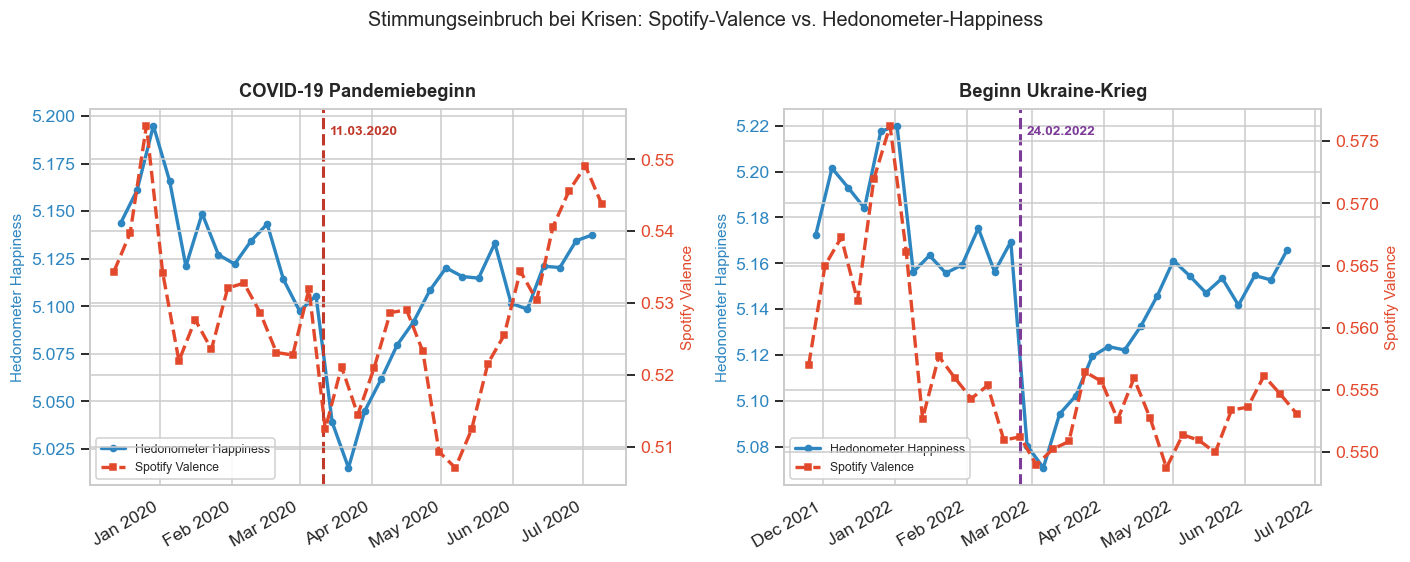

In [35]:
# === Krisenmomente: Valence vs. Hedonometer (2 Panels) ===

import requests

ereignisse = [
    ('COVID-19 Pandemiebeginn', pd.Timestamp('2020-03-11'), '#C0392B'),
    ('Beginn Ukraine-Krieg',    pd.Timestamp('2022-02-24'), '#7D3C98'),
]

# Hedonometer laden (gecacht wenn hedo_weekly bereits im Kernel vorhanden)
if 'hedo_weekly' not in dir():
    def lade_hedonometer():
        basis = 'https://hedonometer.org/api/v1/happiness/?format=json&limit=10000'
        alle, url = [], basis
        while url:
            data = requests.get(url, timeout=30).json()
            alle.extend(data['objects'])
            naechste = data['meta'].get('next')
            url = f"https://hedonometer.org{naechste}" if naechste else None
        return alle
    print('Lade Hedonometer-Daten …')
    hedo = (pd.DataFrame(lade_hedonometer())[['date', 'happiness']]
            .assign(date=lambda d: pd.to_datetime(d['date']),
                    happiness=lambda d: d['happiness'].astype(float))
            .sort_values('date').reset_index(drop=True))
    hedo_weekly = (hedo.set_index('date')['happiness']
                   .resample('W').mean().reset_index())
    hedo_weekly.columns = ['date', 'happiness']
    print('Fertig.')

# Spotify wöchentlich
sp_weekly = (spotify.groupby('week_date')['valence']
             .mean().reset_index().rename(columns={'week_date': 'date'}))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, (titel, ts, farbe_event) in zip(axes, ereignisse):
    start = ts - pd.DateOffset(months=3)
    ende  = ts + pd.DateOffset(months=4)

    sp = sp_weekly[(sp_weekly['date'] >= start) & (sp_weekly['date'] <= ende)]
    hd = hedo_weekly[(hedo_weekly['date'] >= start) & (hedo_weekly['date'] <= ende)]

    ax2 = ax.twinx()

    ax.plot(hd['date'], hd['happiness'],
            color='#2E86C1', lw=2.2, marker='o', ms=4,
            label='Hedonometer Happiness')
    ax.set_ylabel('Hedonometer Happiness', color='#2E86C1', fontsize=10)
    ax.tick_params(axis='y', labelcolor='#2E86C1')

    ax2.plot(sp['date'], sp['valence'],
             color='#E2492C', lw=2.2, marker='s', ms=4, ls='--',
             label='Spotify Valence')
    ax2.set_ylabel('Spotify Valence', color='#E2492C', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='#E2492C')

    ax.axvline(ts, color=farbe_event, lw=2, ls='--', zorder=5)
    ymax = hd['happiness'].max() if len(hd) else 6.5
    ax.text(ts + pd.Timedelta(days=3), ymax,
            ts.strftime('%d.%m.%Y'),
            color=farbe_event, fontsize=9, va='top', fontweight='bold')

    ax.set_title(titel, fontsize=12, fontweight='bold', pad=8)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    sns.despine(ax=ax, right=False)

    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2,
              loc='lower left', fontsize=8, framealpha=0.9)

fig.suptitle('Stimmungseinbruch bei Krisen: Spotify-Valence vs. Hedonometer-Happiness',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Testpunkt 1

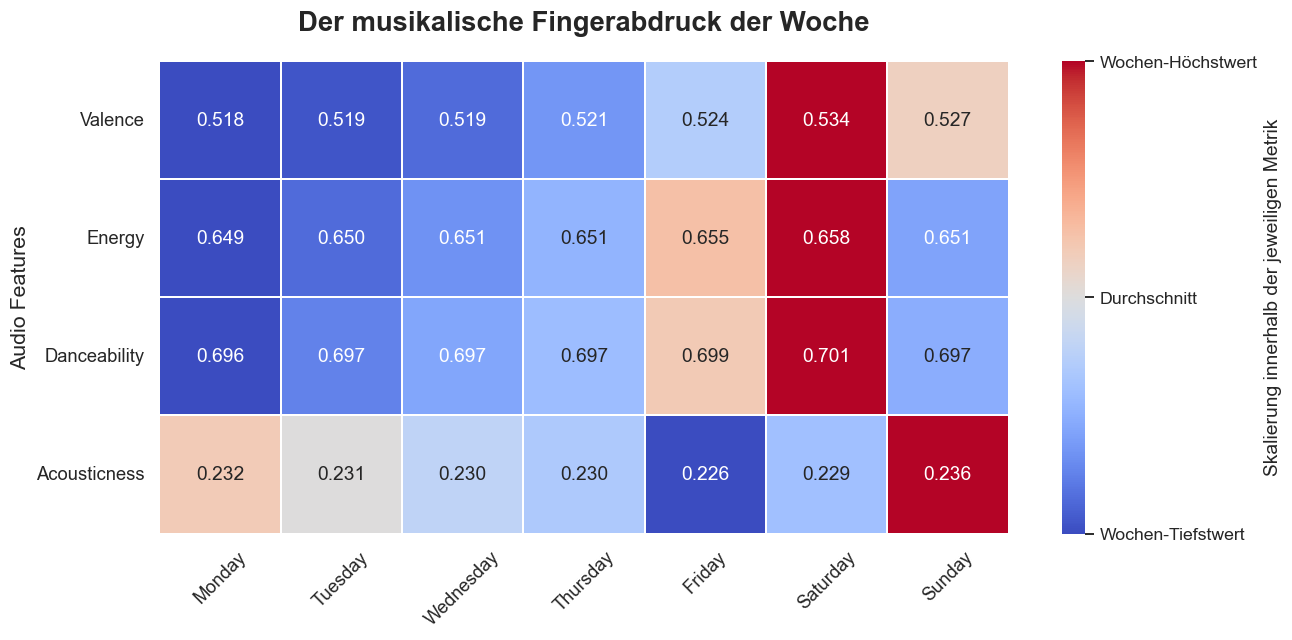

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten laden (Passe den Dateipfad zu eurer CSV-Datei an)
# Tipp: Falls die Datei riesig ist, kannst du zum Testen erstmal nrows=10000 hinzufügen
df = pd.read_csv('../Datensätze/Spotify_Dataset_V3.csv', sep=';')

# --- DATENBEREINIGUNG & VORBEREITUNG ---

# 2. Datum in ein Datetime-Objekt umwandeln und den Wochentag extrahieren
df['Date'] = pd.to_datetime(df['Date'])
df['Weekday'] = df['Date'].dt.day_name()

# 3. Wochentage in die korrekte logische Reihenfolge bringen (sonst sortiert Python alphabetisch)
tage_reihenfolge = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Weekday'] = pd.Categorical(df['Weekday'], categories=tage_reihenfolge, ordered=True)

# 4. Spaltennamen überprüfen (Manchmal sind sie im Kaggle-Datensatz kleingeschrieben)
# Wir nutzen hier zur Sicherheit die Namen in Kleinbuchstaben, pass das ggf. an eure CSV an.
features_of_interest = ['Valence', 'Energy', 'Danceability', 'Acousticness']

# 5. Durchschnittswerte pro Wochentag berechnen
daily_avg = df.groupby('Weekday')[features_of_interest].mean().reset_index()

# 6. DataFrame "schmelzen" (Melt)
# Seaborn arbeitet am besten mit "Long-Format" Daten. Das wandelt unsere Spalten in Zeilen um.
daily_melted = daily_avg.melt(id_vars='Weekday', 
                              value_vars=features_of_interest, 
                              var_name='Audio Feature', 
                              value_name='Average Score')

heatmap_data = daily_avg.set_index('Weekday')[features_of_interest].T

# 1. Die skalierte Version für die Farben berechnen (Min-Max-Skalierung pro Zeile)
heatmap_data_scaled = heatmap_data.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)

# 2. Heatmap zeichnen
plt.figure(figsize=(12, 6))
ax = sns.heatmap(
    heatmap_data_scaled, 
    annot=heatmap_data,  
    fmt=".3f",
    cmap="coolwarm",       
    linewidths=1,
    cbar_kws={'label': 'Skalierung innerhalb der jeweiligen Metrik'} # Label angepasst
)

# --- HIER IST DIE RETTUNG FÜR DIE LEGENDE ---
# Wir greifen uns die Colorbar (Legende) und ersetzen die Zahlen durch Text
cbar = ax.collections[0].colorbar
cbar.set_ticks([0.0, 0.5, 1.0]) # Wir definieren 3 Punkte: Unten, Mitte, Oben
cbar.set_ticklabels(['Wochen-Tiefstwert', 'Durchschnitt', 'Wochen-Höchstwert']) # Text statt Zahlen

# 3. Design-Feinschliff
plt.title('Der musikalische Fingerabdruck der Woche', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('') 
plt.ylabel('Audio Features', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

## Schritt 17: Saisonale Valence-Lücke im Jahresverlauf (2017–2022)
Wie stabil ist der saisonale Stimmungsunterschied über die Jahre? Sommer- vs. Winter-Valence aus dem Spotify Global Top 200.

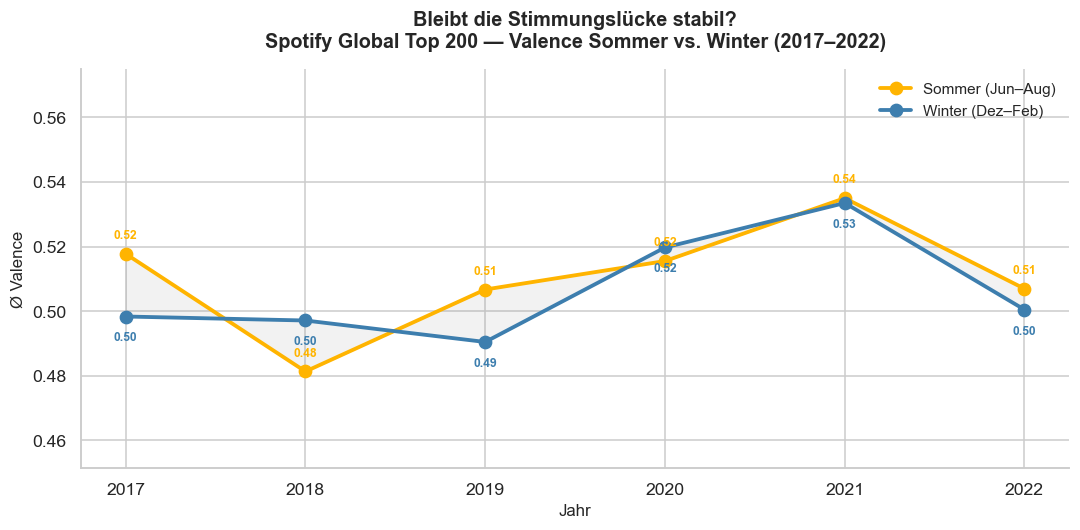

In [40]:
# === Schritt 17: Saisonale Valence-Lücke im Jahresverlauf ===

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FARBE_SOMMER = '#FFB400'
FARBE_WINTER = '#3D7EAE'

# Daten laden & deduplizieren (jeder Song nur einmal pro Tag, da mehrere Künstler-Zeilen)
v3 = pd.read_csv('../Datensätze/Spotify_Dataset_V3.csv', sep=';')
v3['Date'] = pd.to_datetime(v3['Date'], dayfirst=True)
v3 = v3.drop_duplicates(subset=['id', 'Date'])

v3['year']  = v3['Date'].dt.year
v3['month'] = v3['Date'].dt.month

# Nur Sommer- (Jun–Aug) und Wintermonate (Dez–Feb)
saison_map = {6: 'Sommer', 7: 'Sommer', 8: 'Sommer',
              12: 'Winter', 1: 'Winter', 2: 'Winter'}
v3_s = v3[v3['month'].isin(saison_map)].copy()
v3_s['saison'] = v3_s['month'].map(saison_map)

# Jahres-Valence aggregieren (2017–2022: vollständige Sommer UND Winter vorhanden)
jahres_val = (
    v3_s[v3_s['year'].between(2017, 2022)]
    .groupby(['year', 'saison'])['Valence']
    .mean()
    .unstack('saison')
)

fig, ax = plt.subplots(figsize=(10, 5))
jahre = jahres_val.index

ax.plot(jahre, jahres_val['Sommer'], color=FARBE_SOMMER, lw=2.5,
        marker='o', ms=8, label='Sommer (Jun–Aug)')
ax.plot(jahre, jahres_val['Winter'], color=FARBE_WINTER, lw=2.5,
        marker='o', ms=8, label='Winter (Dez–Feb)')

ax.fill_between(jahre, jahres_val['Sommer'], jahres_val['Winter'],
                alpha=0.10, color='gray')

# Werte direkt an den Punkten beschriften
for y in jahre:
    s = jahres_val.loc[y, 'Sommer']
    w = jahres_val.loc[y, 'Winter']
    ax.annotate(f'{s:.2f}', (y, s), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8, color=FARBE_SOMMER, fontweight='bold')
    ax.annotate(f'{w:.2f}', (y, w), textcoords='offset points',
                xytext=(0, -16), ha='center', fontsize=8, color=FARBE_WINTER, fontweight='bold')

ax.set_title('Bleibt die Stimmungslücke stabil?\nSpotify Global Top 200 — Valence Sommer vs. Winter (2017–2022)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Jahr', fontsize=11)
ax.set_ylabel('Ø Valence', fontsize=11)
ax.set_xticks(jahre)
ax.set_ylim(jahres_val.values.min() - 0.03, jahres_val.values.max() + 0.04)
ax.legend(frameon=False, fontsize=10)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

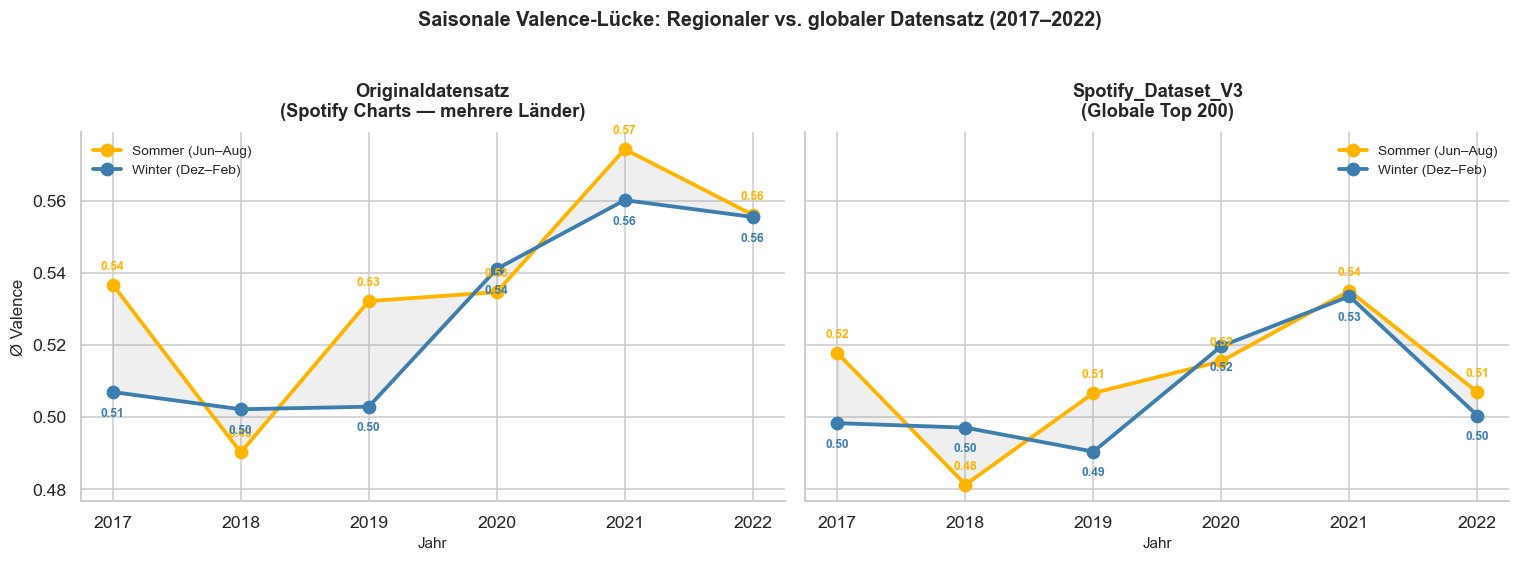

In [9]:
# === Schritt 17b: Vergleich — Originaldatensatz vs. Globaler Top-200-Datensatz ===

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FARBE_SOMMER = '#FFB400'
FARBE_WINTER = '#3D7EAE'
saison_map   = {6:'Sommer',7:'Sommer',8:'Sommer',12:'Winter',1:'Winter',2:'Winter'}

# --- Datensatz 1: Original Spotify (spotify_clean.parquet, alle Länder) ---
sp = pd.read_parquet('../Datensätze/spotify_clean.parquet')
sp_s = sp[sp['month'].isin(saison_map)].copy()
sp_s['saison'] = sp_s['month'].map(saison_map)
sp_val = (sp_s[sp_s['year'].between(2017, 2022)]
          .groupby(['year','saison'])['valence']
          .mean().unstack('saison'))

# --- Datensatz 2: Spotify_Dataset_V3 (Global Top 200) ---
v3 = pd.read_csv('../Datensätze/Spotify_Dataset_V3.csv', sep=';')
v3['Date']  = pd.to_datetime(v3['Date'], dayfirst=True)
v3 = v3.drop_duplicates(subset=['id', 'Date'])
v3['year']  = v3['Date'].dt.year
v3['month'] = v3['Date'].dt.month
v3_s = v3[v3['month'].isin(saison_map)].copy()
v3_s['saison'] = v3_s['month'].map(saison_map)
v3_val = (v3_s[v3_s['year'].between(2017, 2022)]
          .groupby(['year','saison'])['Valence']
          .mean().unstack('saison'))

# --- Plot: zwei Panels nebeneinander ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
titel = [
    'Originaldatensatz\n(Spotify Charts — mehrere Länder)',
    'Spotify_Dataset_V3\n(Globale Top 200)'
]

for ax, val, t in zip(axes, [sp_val, v3_val], titel):
    jahre = val.index
    ax.plot(jahre, val['Sommer'], color=FARBE_SOMMER, lw=2.5,
            marker='o', ms=8, label='Sommer (Jun–Aug)')
    ax.plot(jahre, val['Winter'], color=FARBE_WINTER, lw=2.5,
            marker='o', ms=8, label='Winter (Dez–Feb)')
    ax.fill_between(jahre, val['Sommer'], val['Winter'],
                    alpha=0.12, color='gray')

    for y in jahre:
        s = val.loc[y, 'Sommer']
        w = val.loc[y, 'Winter']
        ax.annotate(f'{s:.2f}', (y, s), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=8,
                    color=FARBE_SOMMER, fontweight='bold')
        ax.annotate(f'{w:.2f}', (y, w), textcoords='offset points',
                    xytext=(0, -16), ha='center', fontsize=8,
                    color=FARBE_WINTER, fontweight='bold')

    ax.set_title(t, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Jahr', fontsize=10)
    ax.set_xticks(jahre)
    ax.legend(frameon=False, fontsize=9)
    sns.despine(ax=ax)

axes[0].set_ylabel('Ø Valence', fontsize=11)
fig.suptitle('Saisonale Valence-Lücke: Regionaler vs. globaler Datensatz (2017–2022)',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()


### Analyse: Saisonale Valence-Lücke im Jahresverlauf

Das Diagramm zeigt die durchschnittliche Valence der Spotify Global Top 200 getrennt nach Sommer (Jun–Aug) und Winter (Dez–Feb) für die Jahre 2017 bis 2022.

**Kernbefund: Die saisonale Lücke ist global überraschend klein.**
Der Unterschied zwischen Sommer- und Winter-Valence beträgt in keinem Jahr mehr als 0,02 Punkte. Ein eindeutiger, konsistenter Saisoneffekt lässt sich auf globaler Ebene damit nicht belegen.

**Scheinbarer Widerspruch zu Schritt 3:**
In Schritt 3 zeigte der länderspezifische Datensatz ein klares saisonales Muster — Valence steigt im Sommer an und fällt im Winter ab. Dieses Ergebnis hier scheint dem zu widersprechen, hat aber eine einfache Erklärung: Der `Spotify_Dataset_V3` enthält die *globalen* Top 200. Dort sind Länder der Südhalbkugel (z.B. Australien, Brasilien, Argentinien) enthalten, deren meteorologischer Sommer in die Monate Dezember bis Februar fällt — also genau dann, wenn es auf der Nordhalbkugel Winter ist. Die entgegengesetzten Saisoneffekte heben sich im globalen Durchschnitt gegenseitig auf.

**Unerwartete Umkehrung in 2018 und 2020:**
In beiden Jahren war die Winter-Valence leicht höher als die Sommer-Valence. Besonders 2020 fällt auf: Im Jahr des ersten globalen COVID-19-Lockdowns war die Valence im Sommer minimal niedriger als im Winter — ein mögliches Indiz, dass die Pandemie das gewohnte saisonale Stimmungsmuster kurzfristig störte.

**Bezug zur Forschungsfrage:**
Dieses Ergebnis unterstreicht, dass länderspezifische Daten (wie in Schritt 3) für die Forschungsfrage deutlich aussagekräftiger sind. Globale Aggregationen verwässern regionale Saisonmuster — kollektive Stimmungsveränderungen lassen sich nur dann zuverlässig identifizieren, wenn die geografische und hemisphärische Perspektive berücksichtigt wird.